# Phase 2 · 10단원 — 편향-분산 트레이드오프

> **모델이 틀렸습니다. 그 오차는 어디서 왔을까요?**

- 원문: <https://aiengineeringfromscratch.com/lesson?path=phases/02-ml-fundamentals/10-bias-variance>
- 예상 시간: 90분 · 선수 지식: Phase 2 1~9단원

---

## 📌 출처 표시 규칙

> 📗 **원문** — 커리큘럼에 있는 내용입니다.

> ✨ **추가** — 원문에는 없고, 제가 넣은 비유·예시·실험입니다.

---

## 🎯 이 단원에서 배우는 것

> 📗 **원문** — "Learning Objectives"

1. 오차를 **편향² + 분산 + 줄일 수 없는 잡음**으로 분해하고, **합이 정말 맞는지** 직접 계산합니다.
2. **복잡도 대 오차**의 U자 곡선을 그리고, 규제가 그 위에서 어디로 움직이는지 봅니다.
3. **이중 하강(double descent)** 을 재현해서, 고전 이론이 현대 모델에 왜 불완전한지 확인합니다.
4. 훈련/테스트 오차로 **편향 문제인지 분산 문제인지 진단**하고, 처방을 고릅니다.

### 🔑 이 단원이 왜 제일 실용적인가

> 📗 원문: "Understanding this tradeoff is the single most useful diagnostic skill in machine learning."
> (이 트레이드오프를 이해하는 게 **머신러닝에서 가장 쓸모 있는 진단 기술 하나**입니다.)

성능이 안 나올 때 할 수 있는 일이 많습니다. 어느 걸 해야 할까요?

| 할 수 있는 일 | 편향 문제일 때 | 분산 문제일 때 |
| --- | --- | --- |
| 데이터를 더 모으기 | ❌ **돈 낭비** | ✅ 가장 확실한 해법 |
| 모델을 더 복잡하게 | ✅ | ❌ **더 나빠집니다** |
| 규제를 세게 | ❌ | ✅ |
| 특징을 더 만들기 | ✅ | ❌ (잡음 특징이면 해롭습니다) |

**정반대입니다.** 진단을 틀리면 노력이 전부 헛수고가 됩니다.
9단원 7절에서 학습 곡선으로 이걸 맛봤죠. 이 단원은 **그 뒤에 있는 수학**입니다.

---

## 📖 목차

| # | 내용 | 출처 |
| --- | --- | --- |
| 0 | 오차는 어디서 오나 | 📗 원문 + ✨ 실험 |
| 1 | 편향 — 체계적으로 빗나감 | 📗 원문 + ✨ 그림 |
| 2 | 분산 — 데이터에 휘둘림 | 📗 원문 + ✨ 그림 |
| 3 | 🔑 🔨 분해 공식을 직접 계산하기 | 📗 원문 + ✨ 검증 |
| 4 | 복잡도 대 오차 — U자 곡선 | 📗 원문 + ✨ 실험 |
| 5 | 규제 = 편향-분산 손잡이 | 📗 원문 + ✨ 실험 |
| 6 | 🔑 이중 하강 — 현대적 관점 | 📗 원문 + ✨ 재현 |
| 7 | 내 모델 진단하기 | 📗 원문 + ✨ 실험 |
| 8 | 앙상블로 분산 줄이기 (11단원 예고) | 📗 원문 + ✨ 실험 |
| 9 | 학습 곡선 다시 보기 | 📗 원문 |
| 10 | 🎒 Ship It — 모델 진단 프롬프트 | 📗 원문 `outputs/` |
| 11 | 📝 자가 점검 퀴즈 (5문항) | 📗 원문 `quiz.json` |
| 12 | 용어 사전 · 연습문제 | 📗 원문 |

---

## 🗺️ 이 단원은 이렇게 이어집니다

> ✨ **추가** — 절이 왜 이 순서인지 먼저 짚고 갑니다. 하나가 다음 하나를 불러옵니다.

**0절**에서 질문을 하나 던집니다. **"테스트 오차가 0.3입니다. 그 0.3은 어디서 온 걸까요?"**
이 질문에 답하면 처방이 자동으로 나옵니다. 그래서 먼저 **오차를 쪼갭니다.**

- **1절 편향** — 모델이 너무 뻣뻣해서 **늘 같은 방향으로 빗나가는** 부분입니다.
- **2절 분산** — 훈련 데이터가 조금 바뀌면 **예측이 확 달라지는** 부분입니다.
- **3절 🔑** — 그 둘에 **잡음**을 더하면 전체 오차가 됩니다. **등식이 정말 맞는지 직접 계산합니다.**
  이 절이 이 단원의 심장입니다. 나머지 절은 다 이 등식을 가지고 노는 겁니다.

등식을 손에 쥐면, 이제 **손잡이를 돌려 볼 수** 있습니다.

- **4절** — 복잡도를 올리면 편향↓ 분산↑. 그래서 전체 오차가 **U자**가 됩니다.
- **5절** — 규제는 **일부러 편향을 늘려 분산을 줄이는** 장치입니다. 2단원 10절 릿지가 왜 되는지가 여기서 풀립니다.
- **6절 🔑** — 그런데 **고전 이론은 여기까지입니다.** 복잡도를 U자 바닥을 지나 **훨씬 더** 올리면
  테스트 오차가 **다시 내려갑니다.** 이게 거대 신경망이 되는 이유입니다. 직접 재현합니다.

이제 실전입니다.

- **7절** — 훈련/테스트 오차만 보고 **편향인지 분산인지 진단**합니다. 처방까지 표로.
- **8절** — 분산을 줄이는 가장 실용적인 도구가 **앙상블**입니다. 배깅이 분산만 줄이는 걸 확인하고,
  **11단원으로 넘어갑니다.**
- **9절** — 9단원 7절의 학습 곡선을 **편향-분산 언어로 다시** 읽습니다.
- **10·11절** — 원문 저장소의 **Ship It 산출물**(진단 프롬프트)과 **퀴즈 5문항**입니다.

### 한 줄로 꿰면

> **오차가 어디서 왔나(0) → 편향(1) + 분산(2) + 잡음 = 전체(3) → 복잡도로 U자를 만들고(4)
> → 규제로 손잡이를 돌리고(5) → 더 올리면 다시 내려가고(6) → 진단하고(7)
> → 앙상블로 분산을 잡고(8) → 학습 곡선으로 확인(9)**

In [1]:
# ── 준비물 ──────────────────────────────────────────────────────
import math

import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

np.set_printoptions(precision=3, suppress=True)

available = {f.name for f in fm.fontManager.ttflist}
for cand in ["Apple SD Gothic Neo", "AppleGothic", "NanumGothic",
             "NanumBarunGothicOTF", "Malgun Gothic", "Noto Sans CJK KR"]:
    if cand in available:
        matplotlib.rcParams["font.family"] = ["DejaVu Sans", cand]
        break
matplotlib.rcParams["axes.unicode_minus"] = False
matplotlib.rcParams["figure.dpi"] = 110

print("준비 끝!")

준비 끝!


## 0️⃣ 오차는 어디서 오나

> 📗 **원문** — "The Problem"

> 모델을 학습시켰습니다. 테스트 데이터에서 오차가 좀 납니다. **그 오차는 어디서 온 걸까요?**
>
> - 모델이 **너무 단순**하면(휜 데이터에 직선 회귀) 진짜 무늬를 **늘 놓칩니다.** 그게 **편향**입니다.
> - 모델이 **너무 복잡**하면(데이터 15개에 20차 다항식) 훈련 데이터는 완벽히 맞히지만
>   새 데이터에서는 **예측이 미친 듯이 흔들립니다.** 그게 **분산**입니다.
>
> 그리고 **둘을 동시에 최소로 만들 수는 없습니다.** 편향을 내리면 분산이 올라갑니다.

### 🧸 비유 — 과녁에 화살 쏘기

화살 10발을 쏘았습니다. 결과가 네 가지로 나옵니다.

| | 분산 낮음 (화살이 몰림) | 분산 높음 (화살이 퍼짐) |
| --- | --- | --- |
| **편향 낮음** (중심 근처) | 🎯 **최고** | 평균은 맞는데 하나하나가 멀다 |
| **편향 높음** (한쪽에 치우침) | 일정하게 **엉뚱한 곳**에 몰림 | 최악 |

- **편향** = 화살 뭉치의 **중심이 과녁 중심에서 얼마나 떨어졌나**
- **분산** = 화살들이 **서로 얼마나 퍼졌나**

조준이 틀어진 활(편향)과 손이 떨리는 사수(분산)는 **완전히 다른 문제**이고, **해법도 다릅니다.**
조준을 고쳐야 할 때 손 떨림을 잡으려 애쓰면 아무 소용이 없죠.

> ✨ **추가** — 가장 단순한 데모부터. 같은 데이터에 직선과 20차 다항식을 얹어 봅니다.

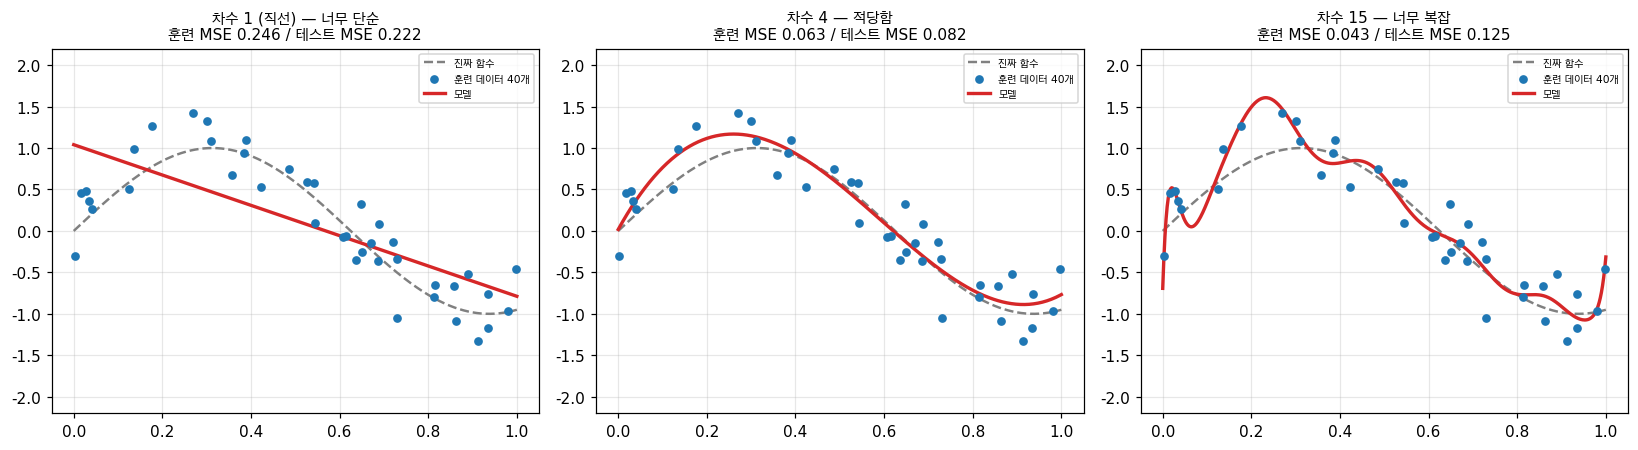

   차수      훈련 MSE       테스트 MSE          간격   진단
--------------------------------------------------------------
    1      0.2460        0.2225     -0.0236   둘 다 큼, 간격 작음 -> 편향
    2      0.1482        0.1173     -0.0309   둘 다 큼, 간격 작음 -> 편향
    4      0.0632        0.0819      0.0188   바닥 근처 -> 괜찮음
    8      0.0602        0.0881      0.0280   훈련만 작음 -> 분산
   15      0.0431        0.1254      0.0823   훈련만 작음 -> 분산

줄일 수 없는 잡음 수준 = 잡음 분산 = 0.0625
=> 어떤 모델도 이 값보다 잘할 수 없습니다. 테스트 MSE의 바닥입니다.
   차수 1은 훈련·테스트가 둘 다 크고 간격이 작습니다 -> **편향** 문제
   차수 15는 훈련은 작은데 테스트가 2배입니다 -> **분산** 문제
   같은 '오차가 크다'인데 원인이 정반대입니다. 이걸 가려내는 게 이 단원입니다.


In [2]:
# ✨ 추가 — 너무 단순한 모델 vs 너무 복잡한 모델
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import make_pipeline

def 진짜함수(x):
    return np.sin(1.6 * np.pi * x)          # 우리가 맞혀야 할 '진실'

잡음표준편차 = 0.25

def 데이터만들기(시드, n=15):
    r = np.random.default_rng(시드)
    x = np.sort(r.uniform(0, 1, n))
    y = 진짜함수(x) + r.normal(0, 잡음표준편차, n)
    return x, y

def 다항모델(차수, 람다=None):
    # ⚠️ StandardScaler 를 끼웁니다. 고차 다항식은 x^15 가 x 보다 훨씬 커서
    #    스케일을 안 맞추면 행렬이 거의 특이해지고 계산이 터집니다 (수학적으로는 같은 모델입니다)
    끝 = LinearRegression() if 람다 is None else Ridge(alpha=람다)
    return make_pipeline(PolynomialFeatures(차수), StandardScaler(), 끝)

훈련개수기본 = 40
x훈련, y훈련 = 데이터만들기(0, 훈련개수기본)
x테스트, y테스트 = 데이터만들기(99, 2000)
격자 = np.linspace(0, 1, 400)

fig, ax = plt.subplots(1, 3, figsize=(15, 4.2))
for a_, 차수, 라벨 in zip(ax, [1, 4, 15],
                          ["차수 1 (직선) — 너무 단순", "차수 4 — 적당함", "차수 15 — 너무 복잡"]):
    m = 다항모델(차수).fit(x훈련[:, None], y훈련)
    a_.plot(격자, 진짜함수(격자), c="gray", ls="--", lw=1.6, label="진짜 함수")
    a_.scatter(x훈련, y훈련, s=22, c="tab:blue", zorder=5,
               label=f"훈련 데이터 {훈련개수기본}개")
    a_.plot(격자, m.predict(격자[:, None]), c="tab:red", lw=2.2, label="모델")
    훈련오차 = float(np.mean((m.predict(x훈련[:, None]) - y훈련) ** 2))
    테스트오차 = float(np.mean((m.predict(x테스트[:, None]) - y테스트) ** 2))
    a_.set_title(f"{라벨}\n훈련 MSE {훈련오차:.3f} / 테스트 MSE {테스트오차:.3f}", fontsize=10)
    a_.set_ylim(-2.2, 2.2); a_.legend(fontsize=7); a_.grid(alpha=0.3)
plt.tight_layout(); plt.show()

print(f"{'차수':>5}{'훈련 MSE':>12}{'테스트 MSE':>14}{'간격':>12}   진단")
print("-" * 62)
for 차수 in [1, 2, 4, 8, 15]:
    m = 다항모델(차수).fit(x훈련[:, None], y훈련)
    tr = float(np.mean((m.predict(x훈련[:, None]) - y훈련) ** 2))
    te = float(np.mean((m.predict(x테스트[:, None]) - y테스트) ** 2))
    바닥 = 잡음표준편차 ** 2
    상대간격 = (te - tr) / max(te, 1e-12)
    if te > 바닥 * 1.6 and 상대간격 < 0.15:
        진단 = "둘 다 큼, 간격 작음 -> 편향"
    elif 상대간격 > 0.3:
        진단 = "훈련만 작음 -> 분산"
    else:
        진단 = "바닥 근처 -> 괜찮음"
    print(f"{차수:>5}{tr:>12.4f}{te:>14.4f}{te-tr:>12.4f}   {진단}")

print(f"\n줄일 수 없는 잡음 수준 = 잡음 분산 = {잡음표준편차**2:.4f}")
print("=> 어떤 모델도 이 값보다 잘할 수 없습니다. 테스트 MSE의 바닥입니다.")
print("   차수 1은 훈련·테스트가 둘 다 크고 간격이 작습니다 -> **편향** 문제")
print("   차수 15는 훈련은 작은데 테스트가 2배입니다 -> **분산** 문제")
print("   같은 '오차가 크다'인데 원인이 정반대입니다. 이걸 가려내는 게 이 단원입니다.")

---

## 1️⃣ 편향 — 체계적으로 빗나감

> 📗 **원문** — "Bias: Systematic Error"
>
> 🔗 **앞 절과 이어서** — 0절에서 차수 1이 "편향 문제"라고 진단했습니다.
> 그런데 **편향이 정확히 뭘까요?** 정의를 봅니다.

> 📗 원문: "If you trained the same model on many different training sets drawn from the same
> distribution and averaged the predictions, bias is the gap between that average and the truth."

### 📐 정의 — 세 단계로 읽으세요

1. **같은 분포에서** 훈련 세트를 여러 개 뽑습니다
2. 각각으로 모델을 학습시켜 **예측을 평균**합니다
3. 그 **평균과 진실의 차이**가 편향입니다

$$\text{편향}(x) = \mathbb{E}[\hat{f}(x)] - f(x)$$

### 🧸 왜 '체계적'인가요?

편향은 **운이 나빠서 생기는 오차가 아닙니다.** 훈련 세트를 100개 뽑아 평균을 내도 **남습니다.**

> 📗 원문: "A straight line fit to a parabola will always miss the curve,
> no matter how much data you give it."
> (포물선에 직선을 맞추면, **데이터를 얼마나 주든** 곡선을 놓칩니다.)

**데이터를 더 모아도 안 고쳐집니다.** 모델 자체를 바꿔야 합니다.

### 📗 증상

```
편향이 높음 (과소적합):
  훈련 오차: 큼
  테스트 오차: 큼
  둘의 간격: 작음
```

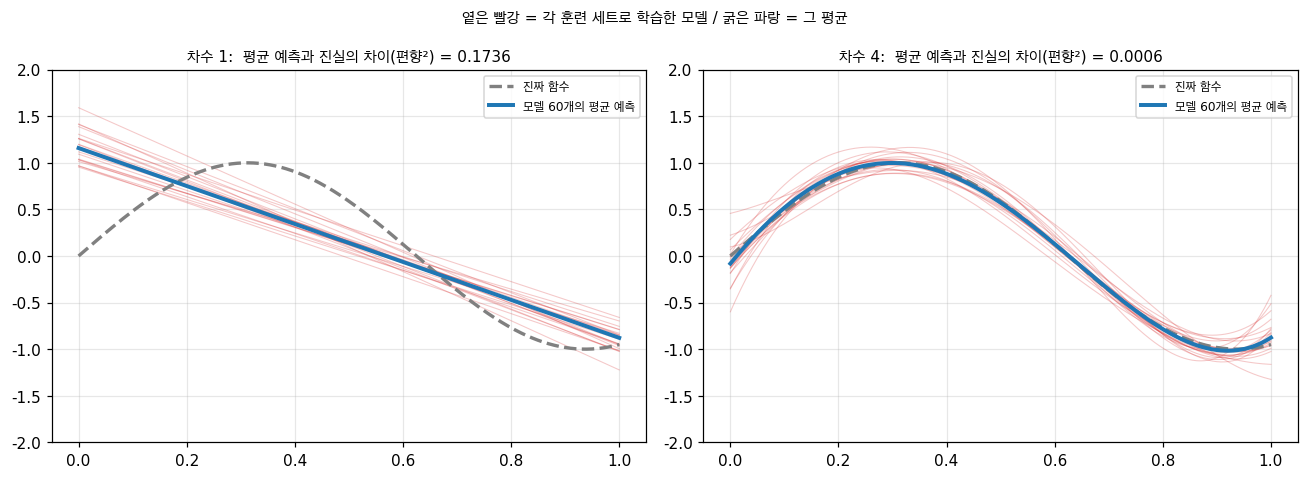

차수  1: 편향² = 0.17356
차수  2: 편향² = 0.05507
차수  3: 편향² = 0.00366
차수  4: 편향² = 0.00062
차수  6: 편향² = 0.00038
차수  8: 편향² = 0.00067
차수 10: 편향² = 0.01497

=> 차수를 올리면 편향²이 줄어듭니다. 모델이 유연해지니까요.
   ⚠️ 차수를 더(12 이상) 올리면 이 추정값 자체가 불안정해집니다.
      모델이 너무 흔들려서 '평균 예측'도 못 믿게 되거든요. 4절에서 다시 봅니다.
   ⭐ 왼쪽 그림의 굵은 파란 선을 보세요. 모델 60개를 평균 냈는데도
      여전히 진짜 함수(회색)와 한참 떨어져 있습니다. **이게 편향입니다.**
      평균을 내도 안 사라지니까 '체계적'이라고 부르는 겁니다.


In [3]:
# ✨ 추가 — '훈련 세트를 여러 개 뽑아 평균 내도 편향은 남는다'를 눈으로 봅니다
반복수 = 60

fig, ax = plt.subplots(1, 2, figsize=(12, 4.4))
for a_, 차수 in zip(ax, [1, 4]):
    예측모음 = []
    for 시드 in range(반복수):
        xs, ys = 데이터만들기(시드, 훈련개수기본)
        m = 다항모델(차수).fit(xs[:, None], ys)
        예측 = m.predict(격자[:, None])
        예측모음.append(예측)
        if 시드 < 20:
            a_.plot(격자, 예측, c="tab:red", lw=0.7, alpha=0.25)
    예측모음 = np.array(예측모음)
    평균예측 = 예측모음.mean(axis=0)

    a_.plot(격자, 진짜함수(격자), c="gray", ls="--", lw=2.2, label="진짜 함수")
    a_.plot(격자, 평균예측, c="tab:blue", lw=2.6, label=f"모델 {반복수}개의 평균 예측")
    편향제곱 = float(np.mean((평균예측 - 진짜함수(격자)) ** 2))
    a_.set_title(f"차수 {차수}:  평균 예측과 진실의 차이(편향²) = {편향제곱:.4f}", fontsize=10)
    a_.set_ylim(-2.0, 2.0); a_.legend(fontsize=8); a_.grid(alpha=0.3)
plt.suptitle("옅은 빨강 = 각 훈련 세트로 학습한 모델 / 굵은 파랑 = 그 평균", fontsize=10)
plt.tight_layout(); plt.show()

for 차수 in [1, 2, 3, 4, 6, 8, 10]:
    예측모음 = np.array([다항모델(차수).fit(데이터만들기(시드, 훈련개수기본)[0][:, None],
                                          데이터만들기(시드, 훈련개수기본)[1])
                        .predict(격자[:, None]) for 시드 in range(반복수)])
    평균예측 = 예측모음.mean(axis=0)
    편향제곱 = float(np.mean((평균예측 - 진짜함수(격자)) ** 2))
    print(f"차수 {차수:>2}: 편향² = {편향제곱:.5f}")

print(f"\n=> 차수를 올리면 편향²이 줄어듭니다. 모델이 유연해지니까요.")
print("   ⚠️ 차수를 더(12 이상) 올리면 이 추정값 자체가 불안정해집니다.")
print("      모델이 너무 흔들려서 '평균 예측'도 못 믿게 되거든요. 4절에서 다시 봅니다.")
print("   ⭐ 왼쪽 그림의 굵은 파란 선을 보세요. 모델 60개를 평균 냈는데도")
print("      여전히 진짜 함수(회색)와 한참 떨어져 있습니다. **이게 편향입니다.**")
print("      평균을 내도 안 사라지니까 '체계적'이라고 부르는 겁니다.")

---

## 2️⃣ 분산 — 데이터에 휘둘림

> 📗 **원문** — "Variance: Sensitivity to Training Data"
>
> 🔗 **앞 절과 이어서** — 1절 그림에서 **옅은 빨간 선들**을 보셨죠.
> 선들이 서로 얼마나 벌어져 있는지가 바로 **분산**입니다.
> 1절에서는 그 선들의 **평균**만 봤고, 이번엔 **퍼진 정도**를 봅니다.

$$\text{분산}(x) = \mathbb{E}\Bigl[\bigl(\hat{f}(x) - \mathbb{E}[\hat{f}(x)]\bigr)^2\Bigr]$$

진실 $f(x)$가 **식에 아예 안 나옵니다.** 분산은 "맞았나 틀렸나"와 무관하고,
**"훈련 데이터를 바꾸면 예측이 얼마나 달라지나"**만 재는 값입니다.

### 🧸 비유 — 손이 떨리는 사수

- **편향**은 조준이 틀어진 겁니다. 과녁이 어디인지 알아야 잴 수 있죠.
- **분산**은 손이 떨리는 겁니다. **과녁이 어디든 상관없이** 잴 수 있습니다.

### 📗 증상

```
분산이 높음 (과적합):
  훈련 오차: 작음
  테스트 오차: 큼
  둘의 간격: 큼
```

> 📗 원문: "A degree-20 polynomial will thread through every training point
> but oscillate wildly between them."
> (20차 다항식은 훈련점 하나하나를 꿰뚫지만 **그 사이에서 미친 듯이 출렁입니다.**)

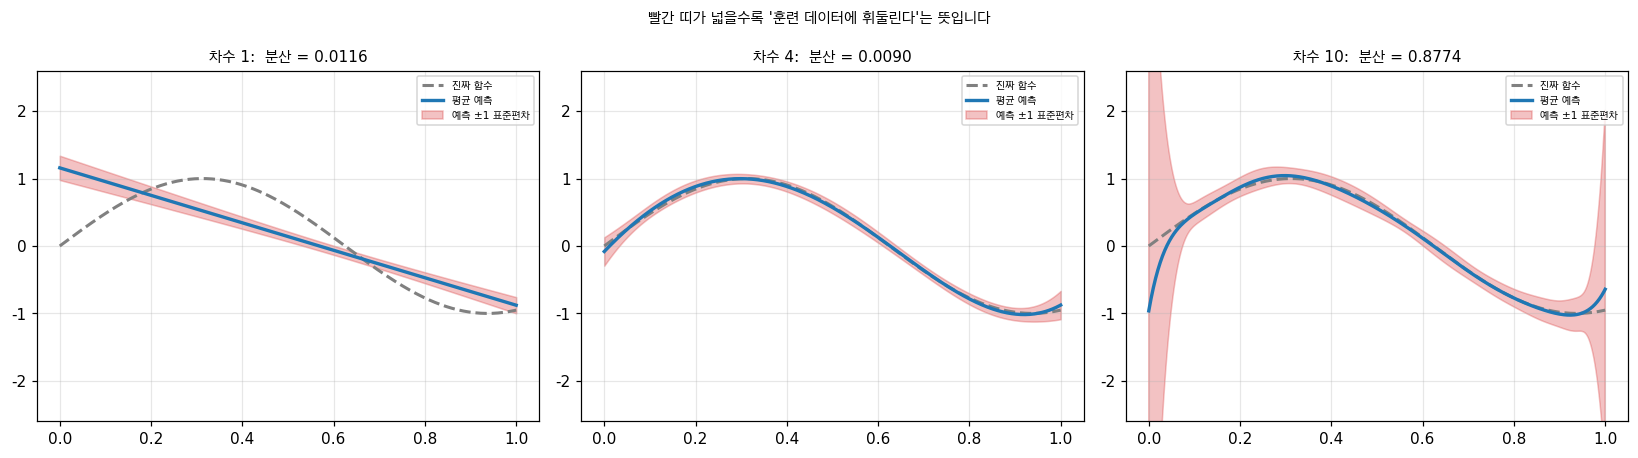

   차수         편향²          분산           합
------------------------------------------
    1     0.17356     0.01161     0.18517
    2     0.05507     0.01139     0.06646
    4     0.00062     0.00898     0.00960
    6     0.00038     0.02690     0.02728
    8     0.00067     0.03900     0.03967
   10     0.01497     0.87739     0.89236

=> ⭐ **두 열이 정반대 방향으로 움직입니다.**
   차수를 올리면 편향²은 줄고 분산은 늡니다. 이게 '트레이드오프'입니다.
   그리고 '합' 열에 최솟값이 있습니다. 거기가 가장 좋은 차수입니다.
   그런데 이 '합'이 정말 전체 테스트 오차와 같을까요? 3절에서 검증합니다.


In [4]:
# ✨ 추가 — 훈련 세트를 바꿀 때 예측이 얼마나 흔들리나
fig, ax = plt.subplots(1, 3, figsize=(15, 4.2))
for a_, 차수 in zip(ax, [1, 4, 10]):
    예측모음 = []
    for 시드 in range(반복수):
        xs, ys = 데이터만들기(시드, 훈련개수기본)
        예측모음.append(다항모델(차수).fit(xs[:, None], ys).predict(격자[:, None]))
    예측모음 = np.array(예측모음)
    평균예측 = 예측모음.mean(axis=0)
    표준편차 = 예측모음.std(axis=0)

    a_.plot(격자, 진짜함수(격자), c="gray", ls="--", lw=2, label="진짜 함수")
    a_.plot(격자, 평균예측, c="tab:blue", lw=2.2, label="평균 예측")
    a_.fill_between(격자, 평균예측 - 표준편차, 평균예측 + 표준편차,
                    color="tab:red", alpha=0.28, label="예측 ±1 표준편차")
    분산 = float(np.mean(예측모음.var(axis=0)))
    a_.set_title(f"차수 {차수}:  분산 = {분산:.4f}", fontsize=10)
    a_.set_ylim(-2.6, 2.6); a_.legend(fontsize=7); a_.grid(alpha=0.3)
plt.suptitle("빨간 띠가 넓을수록 '훈련 데이터에 휘둘린다'는 뜻입니다", fontsize=10)
plt.tight_layout(); plt.show()

print(f"{'차수':>5}{'편향²':>12}{'분산':>12}{'합':>12}")
print("-" * 42)
for 차수 in [1, 2, 4, 6, 8, 10]:
    예측모음 = np.array([다항모델(차수).fit(데이터만들기(시드, 훈련개수기본)[0][:, None],
                                          데이터만들기(시드, 훈련개수기본)[1]).predict(격자[:, None])
                        for 시드 in range(반복수)])
    편향제곱 = float(np.mean((예측모음.mean(axis=0) - 진짜함수(격자)) ** 2))
    분산 = float(np.mean(예측모음.var(axis=0)))
    print(f"{차수:>5}{편향제곱:>12.5f}{분산:>12.5f}{편향제곱+분산:>12.5f}")

print("\n=> ⭐ **두 열이 정반대 방향으로 움직입니다.**")
print("   차수를 올리면 편향²은 줄고 분산은 늡니다. 이게 '트레이드오프'입니다.")
print("   그리고 '합' 열에 최솟값이 있습니다. 거기가 가장 좋은 차수입니다.")
print("   그런데 이 '합'이 정말 전체 테스트 오차와 같을까요? 3절에서 검증합니다.")

---

## 3️⃣ 🔑 🔨 분해 공식을 직접 계산하기

> 📗 **원문** — "The Decomposition" + "Build It: Step 1~3"
>
> 🔗 **이 절이 이 단원의 심장입니다** — 1절에서 편향을, 2절에서 분산을 따로 봤습니다.
> 2절 끝에서 "합에 최솟값이 있다"는 걸 봤죠. 그런데 그 합이 **정말 전체 오차와 같을까요?**
> 등식이 맞는지 **직접 계산해서 확인합니다.**

### 📐 원문 공식

$$\mathbb{E}[\text{오차}] = \underbrace{\bigl(\mathbb{E}[\hat{f}(x)] - f(x)\bigr)^2}_{\text{편향}^2}
+ \underbrace{\mathbb{E}\bigl[(\hat{f}(x) - \mathbb{E}[\hat{f}(x)])^2\bigr]}_{\text{분산}}
+ \underbrace{\sigma^2}_{\text{줄일 수 없는 잡음}}$$

### 🧸 세 항을 말로 풀면

| 항 | 뜻 | 줄일 수 있나 |
| --- | --- | --- |
| **편향²** | 모델 평균이 진실에서 얼마나 벗어났나 | ✅ 모델을 유연하게 |
| **분산** | 훈련 데이터마다 예측이 얼마나 달라지나 | ✅ 데이터를 늘리거나 규제 |
| **잡음 $\sigma^2$** | 데이터 자체의 무작위성 | ❌ **절대 못 줄입니다** |

> 📗 원문: "The noise term is irreducible. No model can do better than sigma^2 on noisy data."
>
> ⭐ 이게 중요합니다. 테스트 MSE가 0.0625라고 나왔는데 잡음 분산이 0.0625면, **완벽한 모델**입니다.
> 더 노력할 게 없습니다. 모르고 계속 튜닝하면 시간만 버립니다.

### 🔨 어떻게 계산하나

$\mathbb{E}[\cdot]$ 는 **훈련 세트를 바꿔 가며 평균**한다는 뜻입니다. 그러니 이렇게 하면 됩니다.

1. 훈련 세트를 $B$개 새로 뽑습니다
2. 각각으로 모델을 학습시켜 **같은 테스트 점들**에 예측합니다
3. 그 $B$개 예측으로 편향²과 분산을 계산합니다
4. 잡음은 우리가 데이터를 만들 때 쓴 $\sigma^2$입니다 (실제 데이터에서는 모릅니다)
5. **세 항의 합**과 **실제 평균 테스트 오차**를 비교합니다

In [5]:
# 📗 원문 Step 1~3 — 편향²·분산·잡음 분해를 직접 계산합니다
def 분해계산(차수, 훈련개수=40, 반복=400, 테스트점수=200, 람다=None, 시드시작=0):
    # 테스트 점은 고정합니다 (같은 x에서 예측이 어떻게 흔들리는지 봐야 하니까요)
    테스트x = np.linspace(0.02, 0.98, 테스트점수)
    진실 = 진짜함수(테스트x)

    예측모음 = np.zeros((반복, 테스트점수))
    for b in range(반복):
        xs, ys = 데이터만들기(시드시작 + b, 훈련개수)
        예측모음[b] = (다항모델(차수, 람다).fit(xs[:, None], ys)
                      .predict(테스트x[:, None]))

    평균예측 = 예측모음.mean(axis=0)
    편향제곱 = float(np.mean((평균예측 - 진실) ** 2))
    분산 = float(np.mean(예측모음.var(axis=0)))
    잡음 = 잡음표준편차 ** 2

    # 실제 평균 테스트 오차: 관측값 y = 진실 + 새 잡음 과 비교합니다
    r = np.random.default_rng(12345)
    관측 = 진실[None, :] + r.normal(0, 잡음표준편차, size=(반복, 테스트점수))
    실제오차 = float(np.mean((예측모음 - 관측) ** 2))

    return {"편향²": 편향제곱, "분산": 분산, "잡음": 잡음,
            "합": 편향제곱 + 분산 + 잡음, "실제 오차": 실제오차}

결과 = 분해계산(차수=4)
print(f"차수 4, 훈련 데이터 {훈련개수기본}개, 훈련 세트 400번 새로 뽑아 계산\n")
for 키, 값 in 결과.items():
    print(f"   {키:<10} = {값:.5f}")
차이 = abs(결과["합"] - 결과["실제 오차"])
print(f"\n   합과 실제 오차의 차이 = {차이:.6f}  ({차이/결과['실제 오차']:.2%})")
print("\n=> ⭐ **등식이 맞습니다.** 편향² + 분산 + 잡음 = 전체 오차.")
print("   차이는 반복을 400번만 했기 때문에 남는 표본 오차입니다.")
print("   반복을 늘리면 0으로 갑니다 (아래에서 확인).")

차수 4, 훈련 데이터 40개, 훈련 세트 400번 새로 뽑아 계산

   편향²        = 0.00033
   분산         = 0.00885
   잡음         = 0.06250
   합          = 0.07168
   실제 오차      = 0.07163

   합과 실제 오차의 차이 = 0.000049  (0.07%)

=> ⭐ **등식이 맞습니다.** 편향² + 분산 + 잡음 = 전체 오차.
   차이는 반복을 400번만 했기 때문에 남는 표본 오차입니다.
   반복을 늘리면 0으로 갑니다 (아래에서 확인).


In [6]:
# ✨ 추가 — 반복 횟수를 늘리면 등식이 더 정확해지는지
print(f"{'반복 횟수':>10}{'합':>12}{'실제 오차':>12}{'차이':>12}{'상대 오차':>12}")
print("-" * 60)
for 반복 in [20, 50, 200, 800]:
    r = 분해계산(차수=4, 반복=반복)
    차 = abs(r["합"] - r["실제 오차"])
    print(f"{반복:>10}{r['합']:>12.5f}{r['실제 오차']:>12.5f}{차:>12.6f}"
          f"{차/r['실제 오차']:>12.2%}")

print("\n=> 반복을 늘릴수록 차이가 줄어듭니다. 등식은 '기댓값'에 대한 것이니까요.")
print("   우리는 유한 번 반복으로 기댓값을 추정하는 중입니다.")
print("\n⚠️ 실제 데이터에서는 이 분해를 할 수 없습니다. 두 가지를 모르기 때문입니다.")
print("   ① 진짜 함수 f(x)  ② 잡음 분산 σ²")
print("   그래서 실무에서는 **훈련/테스트 오차의 간격**으로 간접 진단합니다 (7절).")
print("   이 절은 '그 간접 진단이 왜 통하는지'를 보여 주는 겁니다.")

     반복 횟수           합       실제 오차          차이       상대 오차
------------------------------------------------------------
        20     0.07158     0.07233    0.000748       1.03%
        50     0.07139     0.07209    0.000693       0.96%
       200     0.07065     0.07057    0.000072       0.10%
       800     0.07334     0.07316    0.000181       0.25%

=> 반복을 늘릴수록 차이가 줄어듭니다. 등식은 '기댓값'에 대한 것이니까요.
   우리는 유한 번 반복으로 기댓값을 추정하는 중입니다.

⚠️ 실제 데이터에서는 이 분해를 할 수 없습니다. 두 가지를 모르기 때문입니다.
   ① 진짜 함수 f(x)  ② 잡음 분산 σ²
   그래서 실무에서는 **훈련/테스트 오차의 간격**으로 간접 진단합니다 (7절).
   이 절은 '그 간접 진단이 왜 통하는지'를 보여 주는 겁니다.


> ✨ **추가** — 원문 연습문제 1·2번을 풉니다. **잡음을 0으로 만들면? 데이터를 10배로 늘리면?**

In [7]:
# ✨ 추가 — 원문 연습문제 1번: 잡음이 0이면 어떻게 되나
원래잡음 = 잡음표준편차
print(f"[연습 1] 잡음 σ를 바꿔 봅니다 (차수 4, 훈련 {훈련개수기본}개)\n")
print(f"{'잡음 σ':>8}{'잡음 σ²':>10}{'편향²':>11}{'분산':>11}{'합':>11}{'실제 오차':>12}")
print("-" * 65)
for σ in [0.0, 0.1, 0.25, 0.5]:
    잡음표준편차 = σ
    r = 분해계산(차수=4, 반복=300)
    print(f"{σ:>8.2f}{σ**2:>10.4f}{r['편향²']:>11.5f}{r['분산']:>11.5f}"
          f"{r['합']:>11.5f}{r['실제 오차']:>12.5f}")
잡음표준편차 = 원래잡음

print("\n=> σ=0 이면 '줄일 수 없는 잡음' 항이 정확히 0이 됩니다.")
print("   **그리고 분산도 거의 0이 됩니다.** 훈련 데이터가 매번 똑같아지니까요")
print("   (x는 무작위로 뽑히니 완전히 0은 아닙니다).")
print("   남는 건 편향²뿐입니다. 즉 σ=0이면 **모델의 표현력만 문제**가 됩니다.")
print("\n   그리고 σ가 커질수록 분산도 같이 커집니다. 모델이 잡음을 쫓아가니까요.")
print("   💡 **잡음은 두 번 해롭습니다.** 바닥을 올리고(σ²), 분산도 키웁니다.")

[연습 1] 잡음 σ를 바꿔 봅니다 (차수 4, 훈련 40개)

    잡음 σ     잡음 σ²        편향²         분산          합       실제 오차
-----------------------------------------------------------------
    0.00    0.0000    0.00031    0.00015    0.00046     0.00046
    0.10    0.0100    0.00031    0.00152    0.01183     0.01180
    0.25    0.0625    0.00034    0.00865    0.07150     0.07136
    0.50    0.2500    0.00046    0.03411    0.28457     0.28407

=> σ=0 이면 '줄일 수 없는 잡음' 항이 정확히 0이 됩니다.
   **그리고 분산도 거의 0이 됩니다.** 훈련 데이터가 매번 똑같아지니까요
   (x는 무작위로 뽑히니 완전히 0은 아닙니다).
   남는 건 편향²뿐입니다. 즉 σ=0이면 **모델의 표현력만 문제**가 됩니다.

   그리고 σ가 커질수록 분산도 같이 커집니다. 모델이 잡음을 쫓아가니까요.
   💡 **잡음은 두 번 해롭습니다.** 바닥을 올리고(σ²), 분산도 키웁니다.


In [8]:
# ✨ 추가 — 원문 연습문제 2번: 훈련 데이터를 10배로 늘리면
print("[연습 2] 훈련 데이터 개수를 바꿔 봅니다 (차수 5)\n")
print(f"{'훈련 개수':>10}{'편향²':>11}{'분산':>11}{'잡음':>10}{'합':>11}   무엇이 줄었나")
print("-" * 70)
이전 = None
for n in [15, 30, 80, 300]:
    r = 분해계산(차수=5, 훈련개수=n, 반복=200)
    변화 = ""
    if 이전:
        변화 = f"편향² {r['편향²']-이전['편향²']:+.5f} / 분산 {r['분산']-이전['분산']:+.5f}"
    print(f"{n:>10}{r['편향²']:>11.5f}{r['분산']:>11.5f}{r['잡음']:>10.4f}"
          f"{r['합']:>11.5f}   {변화}")
    이전 = r

print("\n=> ⭐ **데이터를 늘리면 분산만 줄어듭니다. 편향²은 거의 그대로입니다.**")
print("   이게 이 단원의 가장 실용적인 결론입니다.")
print("   · 분산이 문제면 -> 데이터를 더 모으세요. 효과가 있습니다")
print("   · 편향이 문제면 -> 데이터를 더 모아도 소용없습니다. 모델을 바꿔야 합니다")
print("   9단원 7절 학습 곡선에서 '고편향이면 데이터가 소용없다'고 했죠? 그 이유가 이겁니다.")

[연습 2] 훈련 데이터 개수를 바꿔 봅니다 (차수 5)

     훈련 개수        편향²         분산        잡음          합   무엇이 줄었나
----------------------------------------------------------------------
        15    0.03822    5.43862    0.0625    5.53934   
        30    0.00010    0.01692    0.0625    0.07952   편향² -0.03811 / 분산 -5.42170
        80    0.00001    0.00466    0.0625    0.06717   편향² -0.00009 / 분산 -0.01226
       300    0.00002    0.00112    0.0625    0.06364   편향² +0.00001 / 분산 -0.00354

=> ⭐ **데이터를 늘리면 분산만 줄어듭니다. 편향²은 거의 그대로입니다.**
   이게 이 단원의 가장 실용적인 결론입니다.
   · 분산이 문제면 -> 데이터를 더 모으세요. 효과가 있습니다
   · 편향이 문제면 -> 데이터를 더 모아도 소용없습니다. 모델을 바꿔야 합니다
   9단원 7절 학습 곡선에서 '고편향이면 데이터가 소용없다'고 했죠? 그 이유가 이겁니다.


---

## 4️⃣ 복잡도 대 오차 — U자 곡선

> 📗 **원문** — "Model Complexity vs Error"
>
> 🔗 **앞 절과 이어서** — 3절에서 등식을 손에 쥐었습니다.
> 이제 **복잡도를 돌려 가며** 세 항이 어떻게 움직이는지 봅니다.

### 📗 고전적인 U자 곡선

| 복잡도 | 편향 | 분산 | 전체 오차 |
| --- | --- | --- | --- |
| **너무 낮음** | 큼 | 작음 | 큼 (**과소적합**) |
| **딱 좋음** | 중간 | 중간 | **최소** |
| **너무 높음** | 작음 | 큼 | 큼 (**과적합**) |

편향²은 **단조 감소**, 분산은 **단조 증가**합니다. 둘을 더하면 **U자**가 되고,
**U자의 바닥**이 최적 복잡도입니다.

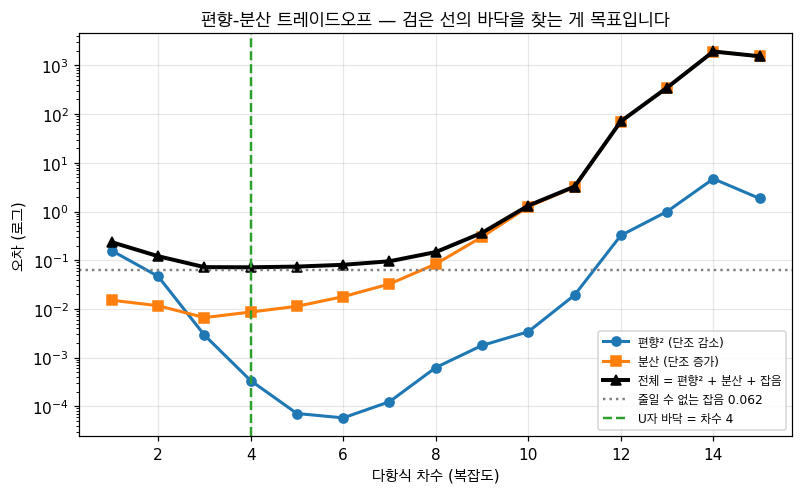

   차수        편향²         분산         전체   상태
------------------------------------------------------
    1    0.15635    0.01505    0.23389   과소적합 (편향이 지배)
    2    0.04656    0.01160    0.12065   과소적합 (편향이 지배)
    3    0.00289    0.00662    0.07200   거의 비슷
    4    0.00034    0.00861    0.07144   <- U자 바닥
    5    0.00007    0.01128    0.07385   거의 비슷
    6    0.00006    0.01785    0.08041   과적합 (분산이 지배)
    7    0.00012    0.03239    0.09502   과적합 (분산이 지배)
    8    0.00062    0.08359    0.14671   과적합 (분산이 지배)
    9    0.00177    0.30068    0.36495   과적합 (분산이 지배)
   10    0.00339    1.25257    1.31846   과적합 (분산이 지배)
   11    0.01917    3.17160    3.25328   과적합 (분산이 지배)
   12    0.32238   70.57962   70.96450   과적합 (분산이 지배)
   13    0.99837  349.54615  350.60701   과적합 (분산이 지배)
   14    4.70122 1932.18039 1936.94411   과적합 (분산이 지배)
   15    1.85321 1543.67279 1545.58850   과적합 (분산이 지배)

=> 차수 1에서는 편향²(0.156)이 분산(0.015)보다 10배 큽니다. **편향이 지배합니다.**
   차수 15에서는 분산(1543.7)이 편향²(1.853)보다 833배 큽니다. 

In [9]:
# ✨ 추가 — 차수를 돌려 가며 세 항을 전부 그립니다
차수들 = list(range(1, 16))
표 = [분해계산(차수=d, 반복=250) for d in 차수들]

편향들 = [t["편향²"] for t in 표]
분산들 = [t["분산"] for t in 표]
합들 = [t["합"] for t in 표]
잡음값 = 표[0]["잡음"]
최적차수 = 차수들[int(np.argmin(합들))]

plt.figure(figsize=(7.4, 4.6))
plt.plot(차수들, 편향들, "o-", lw=2, label="편향² (단조 감소)")
plt.plot(차수들, 분산들, "s-", lw=2, label="분산 (단조 증가)")
plt.plot(차수들, 합들, "^-", lw=2.6, c="black", label="전체 = 편향² + 분산 + 잡음")
plt.axhline(잡음값, c="gray", ls=":", lw=1.6, label=f"줄일 수 없는 잡음 {잡음값:.3f}")
plt.axvline(최적차수, c="tab:green", ls="--", lw=1.6, label=f"U자 바닥 = 차수 {최적차수}")
plt.yscale("log"); plt.xlabel("다항식 차수 (복잡도)"); plt.ylabel("오차 (로그)")
plt.title("편향-분산 트레이드오프 — 검은 선의 바닥을 찾는 게 목표입니다")
plt.legend(fontsize=8); plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()

print(f"{'차수':>5}{'편향²':>11}{'분산':>11}{'전체':>11}   상태")
print("-" * 54)
for d, t in zip(차수들, 표):
    if d == 최적차수:
        상태 = "<- U자 바닥"
    elif t["합"] <= min(합들) * 1.1:
        상태 = "거의 비슷"
    elif d < 최적차수:
        상태 = "과소적합 (편향이 지배)"
    else:
        상태 = "과적합 (분산이 지배)"
    print(f"{d:>5}{t['편향²']:>11.5f}{t['분산']:>11.5f}{t['합']:>11.5f}   {상태}")

print(f"\n=> 차수 1에서는 편향²({편향들[0]:.3f})이 분산({분산들[0]:.3f})보다 "
      f"{편향들[0]/분산들[0]:.0f}배 큽니다. **편향이 지배합니다.**")
print(f"   차수 {차수들[-1]}에서는 분산({분산들[-1]:.1f})이 편향²({편향들[-1]:.3f})보다 "
      f"{분산들[-1]/max(편향들[-1],1e-9):.0f}배 큽니다. **분산이 지배합니다.**")
print(f"   차수 {최적차수}에서 둘의 합이 최소입니다. 어느 한쪽을 0으로 만드는 게 목표가 아닙니다.")
print(f"\n   ⚠️ 그리고 전체 오차는 절대 {잡음값:.4f} 아래로 못 내려갑니다. 회색 점선이 바닥입니다.")

---

## 5️⃣ 규제 = 편향-분산 손잡이

> 📗 **원문** — "Regularization as Bias-Variance Control" + "Build It: Step 5"
>
> 🔗 **앞 절과 이어서** — 4절에서 **차수**로 U자 위를 움직였습니다.
> 그런데 차수는 **정수**입니다. 4와 5 사이는 못 가죠.
> 규제는 **연속적인 손잡이**를 줍니다. 그리고 더 중요한 게 있습니다.

> 📗 원문: "Regularization deliberately increases bias to reduce variance."
> (규제는 **일부러 편향을 늘려 분산을 줄입니다.**)

### 📗 규제의 종류

| 방법 | 하는 일 |
| --- | --- |
| **L2 (릿지)** | 모든 가중치를 0 쪽으로 **줄입니다.** 특징은 다 남기고 영향력만 줄임 |
| **L1 (라쏘)** | 일부 가중치를 **정확히 0으로.** 특징 선택이 됩니다 (8단원 7절) |
| **드롭아웃** | 학습 중 뉴런을 무작위로 끕니다. 중복된 표현을 강제 |
| **조기 종료** | 훈련 데이터를 완전히 맞추기 **전에 멈춥니다** |

### 🧸 비유 — 손을 묶어 두기

20차 다항식은 **움직일 수 있는 폭이 너무 큽니다.** 그래서 잡음을 쫓아갑니다.
규제는 그 손을 **살짝 묶어 둡니다.** 진짜 무늬를 조금 놓치게 되지만(편향↑),
잡음도 못 쫓아갑니다(분산↓).

**그 손해보다 이득이 크면 전체 오차가 줄어듭니다.** 아래에서 확인합니다.

차수 15 고정 (4절에서 과적합이었던 복잡도)

         λ        편향²         분산         전체   상태
--------------------------------------------------------
     1e-08    0.00248    0.19661    0.26159   규제 부족
     1e-06    0.00082    0.08644    0.14977   규제 부족
    0.0001    0.00031    0.02547    0.08828   규제 부족
     0.001    0.00018    0.01484    0.07752   규제 부족
      0.01    0.00060    0.01053    0.07363   <- 최소
       0.1    0.00530    0.00887    0.07667   규제 과다
         1    0.03076    0.01334    0.10660   규제 과다
        10    0.06681    0.00983    0.13914   규제 과다
       100    0.14379    0.01122    0.21751   규제 과다

=> ⭐ 규제를 λ=1e-08 에서 λ=100 로 세게 하면
   편향²: 0.00248 -> 0.14379   **58배 늘어납니다**
   분산  : 0.19661 -> 0.01122   **18배 줄어듭니다**
   📗 원문의 '일부러 편향을 늘려 분산을 줄인다'가 그대로 보입니다.

   그리고 전체 오차는 λ=0.01 에서 최소(0.07363)입니다.
   규제가 너무 약하면(λ=1e-08) 분산이 0.1966 로 커지고,
   너무 세면(λ=100) 편향²이 0.1438 로 커집니다.
   **양쪽 다 나쁩니다.** 퀴즈 3번의 답이 이겁니다 —
   분산 감소가 편향 증가를 능가하는 구간에서만 전체 오차가 줄어듭니다.


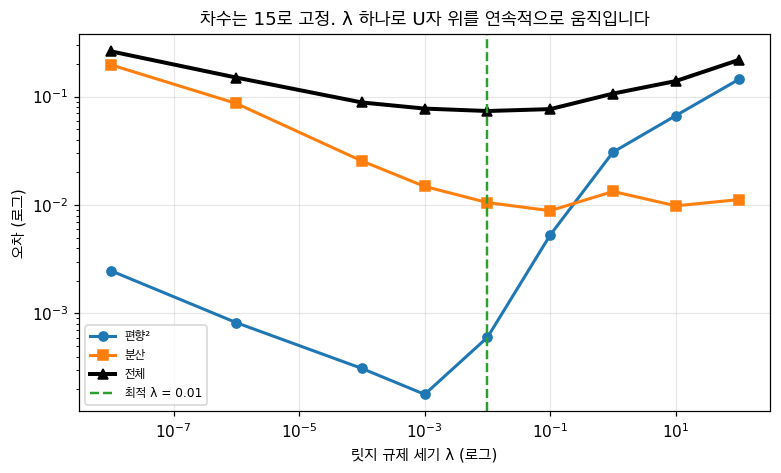

In [10]:
# ✨ 추가 — 원문 연습문제 3번: 차수 15를 고정하고 λ를 0부터 올려 봅니다
람다들 = [1e-8, 1e-6, 1e-4, 1e-3, 1e-2, 1e-1, 1.0, 10.0, 100.0]
릿지표 = [분해계산(차수=15, 람다=λ, 반복=250) for λ in 람다들]

최적람다 = 람다들[int(np.argmin([t["합"] for t in 릿지표]))]
print("차수 15 고정 (4절에서 과적합이었던 복잡도)\n")
print(f"{'λ':>10}{'편향²':>11}{'분산':>11}{'전체':>11}   상태")
print("-" * 56)
for λ, t in zip(람다들, 릿지표):
    상태 = "<- 최소" if λ == 최적람다 else ("규제 부족" if λ < 최적람다 else "규제 과다")
    print(f"{λ:>10g}{t['편향²']:>11.5f}{t['분산']:>11.5f}{t['합']:>11.5f}   {상태}")

최적칸 = int(np.argmin([t["합"] for t in 릿지표]))
최적 = 릿지표[최적칸]
왼, 오 = 릿지표[0], 릿지표[-1]
print(f"\n=> ⭐ 규제를 λ={람다들[0]:g} 에서 λ={람다들[-1]:g} 로 세게 하면")
print(f"   편향²: {왼['편향²']:.5f} -> {오['편향²']:.5f}   "
      f"**{오['편향²']/max(왼['편향²'],1e-12):.0f}배 늘어납니다**")
print(f"   분산  : {왼['분산']:.5f} -> {오['분산']:.5f}   "
      f"**{왼['분산']/max(오['분산'],1e-12):.0f}배 줄어듭니다**")
print("   📗 원문의 '일부러 편향을 늘려 분산을 줄인다'가 그대로 보입니다.")
print(f"\n   그리고 전체 오차는 λ={최적람다:g} 에서 최소({최적['합']:.5f})입니다.")
작은쪽 = 릿지표[0]
print(f"   규제가 너무 약하면(λ={람다들[0]:g}) 분산이 {작은쪽['분산']:.4f} 로 커지고,")
print(f"   너무 세면(λ={람다들[-1]:g}) 편향²이 {릿지표[-1]['편향²']:.4f} 로 커집니다.")
print(f"   **양쪽 다 나쁩니다.** 퀴즈 3번의 답이 이겁니다 —")
print("   분산 감소가 편향 증가를 능가하는 구간에서만 전체 오차가 줄어듭니다.")

plt.figure(figsize=(7.2, 4.4))
plt.plot(람다들, [t["편향²"] for t in 릿지표], "o-", lw=2, label="편향²")
plt.plot(람다들, [t["분산"] for t in 릿지표], "s-", lw=2, label="분산")
plt.plot(람다들, [t["합"] for t in 릿지표], "^-", lw=2.6, c="black", label="전체")
plt.axvline(최적람다, c="tab:green", ls="--", lw=1.6, label=f"최적 λ = {최적람다:g}")
plt.xscale("log"); plt.yscale("log")
plt.xlabel("릿지 규제 세기 λ (로그)"); plt.ylabel("오차 (로그)")
plt.title("차수는 15로 고정. λ 하나로 U자 위를 연속적으로 움직입니다")
plt.legend(fontsize=8); plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()

In [11]:
# ✨ 추가 — '규제하면 높은 차수를 써도 된다'를 확인합니다
print("규제 없는 최적(4절) vs 규제 있는 고차수\n")
무규제최적 = min(표, key=lambda t: t["합"])
무규제차수 = 차수들[int(np.argmin([t["합"] for t in 표]))]
규제최적 = min(릿지표, key=lambda t: t["합"])

print(f"{'설정':<30}{'편향²':>11}{'분산':>11}{'전체':>11}")
print("-" * 64)
print(f"{f'차수 {무규제차수}, 규제 없음':<29}{무규제최적['편향²']:>11.5f}"
      f"{무규제최적['분산']:>11.5f}{무규제최적['합']:>11.5f}")
print(f"{f'차수 15, λ={최적람다:g}':<29}{규제최적['편향²']:>11.5f}"
      f"{규제최적['분산']:>11.5f}{규제최적['합']:>11.5f}")

차 = 규제최적["합"] - 무규제최적["합"]
print(f"\n=> 전체 오차 차이: {차:+.5f}")
if 차 < 0:
    print("   규제를 쓴 고차수 모델이 더 좋습니다.")
else:
    print("   이 데이터에서는 비슷하거나 규제 쪽이 조금 나쁩니다.")
print("\n💡 실무에서 중요한 점 — **복잡도를 줄이는 것과 규제를 세게 하는 것은 거의 같은 일**입니다.")
print("   그래서 보통 이렇게 합니다: **모델을 넉넉하게 크게 잡고, 규제로 조절한다.**")
print("   차수를 하나하나 시도하는 것보다 λ를 연속으로 훑는 게 쉽거든요.")
print("   9단원 8절의 검증 곡선을 λ에 대해 그리면 됩니다.")

규제 없는 최적(4절) vs 규제 있는 고차수

설정                                    편향²         분산         전체
----------------------------------------------------------------
차수 4, 규제 없음                      0.00034    0.00861    0.07144
차수 15, λ=0.01                    0.00060    0.01053    0.07363

=> 전체 오차 차이: +0.00219
   이 데이터에서는 비슷하거나 규제 쪽이 조금 나쁩니다.

💡 실무에서 중요한 점 — **복잡도를 줄이는 것과 규제를 세게 하는 것은 거의 같은 일**입니다.
   그래서 보통 이렇게 합니다: **모델을 넉넉하게 크게 잡고, 규제로 조절한다.**
   차수를 하나하나 시도하는 것보다 λ를 연속으로 훑는 게 쉽거든요.
   9단원 8절의 검증 곡선을 λ에 대해 그리면 됩니다.


---

## 6️⃣ 🔑 이중 하강 — 현대적 관점

> 📗 **원문** — "Double Descent: The Modern Perspective"
>
> 🔗 **여기서 4절의 U자가 깨집니다** — 4절은 "복잡도를 바닥 지나 더 올리면 계속 나빠진다"고 했습니다.
> **고전 이론은 거기까지입니다.** 2019년 이후 연구가 뒤집었습니다.

> 📗 원문: "If you keep increasing model capacity far past the interpolation threshold
> ... test error can decrease again."
> (**보간 임곗값**을 훨씬 지나 용량을 계속 올리면 테스트 오차가 **다시 내려갈 수 있습니다.**)

### 📐 보간 임곗값(interpolation threshold)이 뭔가요?

**파라미터 수 $p$ = 훈련 데이터 수 $n$** 인 지점입니다.
여기서 모델은 **훈련 데이터를 딱 완벽하게 맞출 수 있을 만큼의** 용량을 갖습니다.

| 영역 | 파라미터 vs 샘플 | 어떻게 되나 |
| --- | --- | --- |
| **과소 파라미터** | $p \ll n$ | 고전 트레이드오프가 적용됩니다 (4절) |
| **보간 임곗값** | $p \approx n$ | ⚠️ **분산이 폭발하고 테스트 오차가 치솟습니다** |
| **과대 파라미터** | $p \gg n$ | **암묵적 규제가 작동해서 오차가 다시 내려갑니다** |

### 🧸 왜 이런 일이 벌어지나요?

> 📗 원문 설명을 풀면 이렇습니다.

**$p = n$ 일 때**: 훈련점을 전부 꿰뚫는 해가 **딱 하나**입니다. 선택의 여지가 없어요.
그 하나가 아주 이상한 모양이어도 **그걸 써야 합니다.** 데이터가 조금 바뀌면 그 해가 확 달라집니다.

**$p \gg n$ 일 때**: 훈련점을 전부 꿰뚫는 해가 **무수히 많습니다.**
그러면 학습 알고리즘이 **그중 가장 단순한 것**을 고릅니다(최소 노름 해).
이 "단순한 걸 고르는 성향"이 **암묵적 규제**입니다.

### 🧸 비유 — 점 세 개를 지나는 곡선 그리기

점 3개를 지나는 **2차 곡선**은 딱 하나입니다. 점이 조금 움직이면 곡선이 확 달라집니다.
그런데 점 3개를 지나는 **곡선 전체**를 생각하면 무수히 많습니다.
그중 **가장 완만한 것**을 고르라고 하면? **안정적인 답**이 나옵니다.

### 📗 실무 결론

> "The worst place to be is right at the threshold."
> (**가장 나쁜 자리가 바로 임곗값**입니다.)

임곗값 **아래에 충분히 머물거나**(명시적 규제와 함께), **훨씬 위로 가세요.**

In [12]:
# ✨ 추가 — 이중 하강을 직접 재현합니다
# 설정: y = x[:,:k] @ β + 잡음.  x는 Pmax차원인데, 앞에서 p개만 모델에 씁니다
Pmax, 쓰이는특징수 = 400, 20
베타 = np.zeros(Pmax)
베타[:쓰이는특징수] = np.random.default_rng(1).normal(0, 1, 쓰이는특징수) / np.sqrt(쓰이는특징수)

def 선형데이터(시드, n, 잡음=0.3):
    r = np.random.default_rng(시드)
    X = r.normal(size=(n, Pmax))
    y = X @ 베타 + r.normal(0, 잡음, n)
    return X, y

n훈련 = 40
X훈련d, y훈련d = 선형데이터(0, n훈련)
X테스트d, y테스트d = 선형데이터(99, 4000)

print(f"훈련 데이터 n = {n훈련}개 / 진짜로 쓰이는 특징 {쓰이는특징수}개")
print(f"모델에 넣는 특징 수 p 를 2부터 {Pmax}까지 늘려 봅니다.")
print("해는 '최소 노름 최소제곱'(pinv)으로 구합니다 — 명시적 규제는 없습니다.\n")
print(f"{'p':>5}{'p/n':>7}{'훈련 MSE':>12}{'테스트 MSE':>14}{'||w||':>10}   영역")
print("-" * 68)

이중하강 = []
for p in [2, 5, 10, 20, 30, 36, 39, 40, 41, 44, 50, 60, 80, 120, 200, 400]:
    A = X훈련d[:, :p]
    w = np.linalg.pinv(A, rcond=1e-14) @ y훈련d        # 최소 노름 해
    훈련 = float(np.mean((A @ w - y훈련d) ** 2))
    테스트 = float(np.mean((X테스트d[:, :p] @ w - y테스트d) ** 2))
    이중하강.append((p, 훈련, 테스트, float(np.linalg.norm(w))))
    영역 = "과소 파라미터" if p < n훈련 * 0.9 else \
           ("⚠️ 보간 임곗값" if p <= n훈련 * 1.1 else "과대 파라미터")
    print(f"{p:>5}{p/n훈련:>7.2f}{훈련:>12.5f}{테스트:>14.3f}"
          f"{np.linalg.norm(w):>10.2f}   {영역}")

봉우리 = max(이중하강, key=lambda r: r[2])
뒤쪽 = [r for r in 이중하강 if r[0] > 봉우리[0]]
뒤최저 = min(뒤쪽, key=lambda r: r[2]) if 뒤쪽 else None
앞최저 = min([r for r in 이중하강 if r[0] < 봉우리[0]], key=lambda r: r[2])

print(f"\n=> ⭐ **테스트 MSE 봉우리가 p = {봉우리[0]} 에서 {봉우리[2]:.1f} 입니다.**")
print(f"   훈련 데이터가 n = {n훈련}개니까, 정확히 **보간 임곗값(p = n)** 입니다.")
print(f"   첫 번째 바닥: p = {앞최저[0]} 에서 {앞최저[2]:.4f}  (고전적 U자의 바닥)")
if 뒤최저:
    print(f"   두 번째 바닥: p = {뒤최저[0]} 에서 {뒤최저[2]:.4f}  "
          f"⭐ **임곗값보다 {봉우리[2]/뒤최저[2]:.0f}배 좋습니다**")
    if 뒤최저[2] > 앞최저[2]:
        print(f"\n   ⚠️ 정직하게 짚을 점: 두 번째 바닥({뒤최저[2]:.3f})이 "
              f"첫 번째 바닥({앞최저[2]:.3f})보다 **나쁩니다.**")
        print("      '이중 하강'은 '더 올리면 더 좋아진다'는 뜻이 아닙니다.")
        print("      '임곗값을 지나면 다시 내려간다'는 뜻일 뿐이에요.")
        print("      이 데이터에서는 고전적 최적(p=20)이 여전히 제일 좋습니다.")
        print("      📗 원문의 결론도 그래서 '임곗값을 피하라'입니다. "
              "'무조건 크게'가 아니고요.")
print(f"\n   '||w||' 열을 보세요. p={봉우리[0]} 에서 {봉우리[3]:.1f} 로 폭발하고,")
if 뒤최저:
    print(f"   p={뒤최저[0]} 에서 {뒤최저[3]:.2f} 로 다시 작아집니다.")
print("   이게 **암묵적 규제**입니다. 해가 많으면 그중 가장 '작은' 걸 고르니까요.")

훈련 데이터 n = 40개 / 진짜로 쓰이는 특징 20개
모델에 넣는 특징 수 p 를 2부터 400까지 늘려 봅니다.
해는 '최소 노름 최소제곱'(pinv)으로 구합니다 — 명시적 규제는 없습니다.

    p    p/n      훈련 MSE       테스트 MSE     ||w||   영역
--------------------------------------------------------------------
    2   0.05     0.33717         0.409      0.10   과소 파라미터
    5   0.12     0.27949         0.274      0.32   과소 파라미터
   10   0.25     0.11362         0.279      0.62   과소 파라미터
   20   0.50     0.02680         0.165      0.68   과소 파라미터
   30   0.75     0.01156         0.274      0.70   과소 파라미터
   36   0.90     0.00078        24.803      4.94   ⚠️ 보간 임곗값
   39   0.97     0.00057        10.706      3.25   ⚠️ 보간 임곗값
   40   1.00     0.00000       990.626     31.33   ⚠️ 보간 임곗값
   41   1.02     0.00000        27.581      5.35   ⚠️ 보간 임곗값
   44   1.10     0.00000         0.772      0.88   ⚠️ 보간 임곗값
   50   1.25     0.00000         0.422      0.69   과대 파라미터
   60   1.50     0.00000         0.333      0.58   과대 파라미터
   80   2.00     0.00000         0.309      0.4

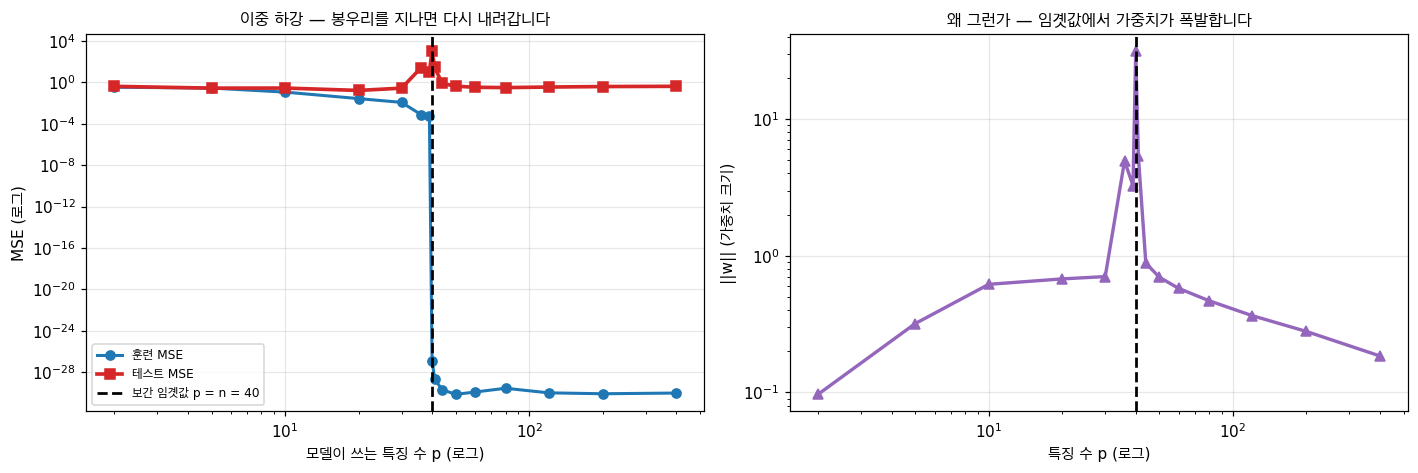

📗 원문이 짚는 네 가지 관찰
   ① 선형 모델·결정 트리·신경망에서 **모두** 나타납니다
   ② 보간 영역에서는 **데이터를 더 모으는 게 해로울 수도** 있습니다 (샘플 이중 하강)
   ③ 훈련 에폭을 늘려도 같은 일이 생깁니다 (에폭 이중 하강)
   ④ 규제는 봉우리를 **완만하게 만들지만 없애지는 못합니다**

💡 그래서 거대 신경망이 되는 겁니다.
   파라미터가 데이터보다 1000배 많은 모델이 왜 일반화되나? 고전 이론으로는 설명이 안 됩니다.
   **임곗값을 한참 지나 과대 파라미터 영역에 있기 때문**입니다.

   ⚠️ 그렇다고 4절이 틀린 건 아닙니다. 📗 원문: 'not wrong, but incomplete'.
      p << n 인 고전 영역에서는 4절의 U자가 정확히 맞습니다.


In [13]:
# ✨ 추가 — 이중 하강을 그림으로
fig, ax = plt.subplots(1, 2, figsize=(13, 4.4))
ps = [r[0] for r in 이중하강]

ax[0].plot(ps, [r[1] for r in 이중하강], "o-", lw=2, label="훈련 MSE")
ax[0].plot(ps, [r[2] for r in 이중하강], "s-", lw=2.4, c="tab:red", label="테스트 MSE")
ax[0].axvline(n훈련, c="black", ls="--", lw=1.8, label=f"보간 임곗값 p = n = {n훈련}")
ax[0].set_xscale("log"); ax[0].set_yscale("log")
ax[0].set_xlabel("모델이 쓰는 특징 수 p (로그)"); ax[0].set_ylabel("MSE (로그)")
ax[0].set_title("이중 하강 — 봉우리를 지나면 다시 내려갑니다", fontsize=11)
ax[0].legend(fontsize=8); ax[0].grid(alpha=0.3)

ax[1].plot(ps, [r[3] for r in 이중하강], "^-", lw=2.2, c="tab:purple")
ax[1].axvline(n훈련, c="black", ls="--", lw=1.8)
ax[1].set_xscale("log"); ax[1].set_yscale("log")
ax[1].set_xlabel("특징 수 p (로그)"); ax[1].set_ylabel("||w|| (가중치 크기)")
ax[1].set_title("왜 그런가 — 임곗값에서 가중치가 폭발합니다", fontsize=11)
ax[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

print("📗 원문이 짚는 네 가지 관찰")
print("   ① 선형 모델·결정 트리·신경망에서 **모두** 나타납니다")
print("   ② 보간 영역에서는 **데이터를 더 모으는 게 해로울 수도** 있습니다 (샘플 이중 하강)")
print("   ③ 훈련 에폭을 늘려도 같은 일이 생깁니다 (에폭 이중 하강)")
print("   ④ 규제는 봉우리를 **완만하게 만들지만 없애지는 못합니다**")
print("\n💡 그래서 거대 신경망이 되는 겁니다.")
print("   파라미터가 데이터보다 1000배 많은 모델이 왜 일반화되나? 고전 이론으로는 설명이 안 됩니다.")
print("   **임곗값을 한참 지나 과대 파라미터 영역에 있기 때문**입니다.")
print("\n   ⚠️ 그렇다고 4절이 틀린 건 아닙니다. 📗 원문: 'not wrong, but incomplete'.")
print("      p << n 인 고전 영역에서는 4절의 U자가 정확히 맞습니다.")

---

## 7️⃣ 내 모델 진단하기

> 📗 **원문** — "Diagnosing Your Model" + "Practical Strategies"
>
> 🔗 **여기서 실전으로 넘어옵니다** — 3절에서 봤듯 **실제 데이터에서는 분해를 할 수 없습니다.**
> 진짜 함수도 잡음 분산도 모르니까요.
> 그럼 뭘 보고 진단하죠? **훈련 오차와 테스트 오차, 둘뿐입니다.**

### 📗 진단 표 — 이 표만 외우면 됩니다

| 증상 | 진단 | 처방 |
| --- | --- | --- |
| 훈련 오차 **큼** + 테스트 오차 **큼** | **편향** | 특징 추가, 복잡한 모델, 규제 약하게 |
| 훈련 오차 **작음** + 테스트 오차 **큼** | **분산** | **데이터 추가**, 규제 세게, 단순한 모델 |
| 훈련 오차 작음 + 테스트 오차 작음 | **좋은 적합** | 배포하세요 |
| 훈련 오차 ↓ 인데 테스트 오차 ↑ | **과적합 진행 중** | **조기 종료** |

### 📗 처방 (원문 "Practical Strategies")

**편향이 문제일 때**
- 다항·상호작용 특징 추가 (8단원 2·6절)
- 더 유연한 모델 (선형 대신 트리 앙상블)
- 규제 세기 **낮추기**
- 더 오래 학습 (아직 수렴 안 됐다면)

**분산이 문제일 때**
- **훈련 데이터 더 모으기** ← 3절에서 봤듯 가장 확실합니다
- **배깅 (랜덤 포레스트)** ← 8절
- 규제 **세게** (λ↑, 드롭아웃↑)
- 특징 선택 (잡음 특징 제거 — 8단원 7절)
- 교차검증으로 조기 발견 (9단원 3절)

> ⚠️ **Ship It 산출물이 경고하는 흔한 실수** (10절에서 전문을 봅니다)
> - 편향 문제에 **"데이터를 더 모으세요"**를 첫 처방으로 주기 → 소용없습니다
> - 분산 문제에 **더 복잡한 모델** 권하기 → 더 나빠집니다
> - 훈련·테스트가 **둘 다 큰데 과적합**이라고 진단하기 → 그건 과소적합입니다

In [14]:
# ✨ 추가 — 진단기를 코드로 만들고, 모델 네 개를 진단해 봅니다
def 진단하기(훈련오차, 테스트오차, 잡음바닥=None, 상대간격한계=0.30):
    간격 = 테스트오차 - 훈련오차
    상대간격 = 간격 / max(테스트오차, 1e-12)
    바닥근처 = (잡음바닥 is not None) and (테스트오차 < 잡음바닥 * 1.4)

    if 바닥근처:
        return "잡음 바닥", "더 할 게 없습니다. 특징을 새로 구하거나 데이터를 정제하세요"
    if 상대간격 > 상대간격한계:
        return "분산 (과적합)", "데이터 추가 / 규제 세게 / 단순한 모델 / 배깅"
    if 잡음바닥 is not None and 테스트오차 > 잡음바닥 * 1.6:
        return "편향 (과소적합)", "특징 추가 / 복잡한 모델 / 규제 약하게"
    return "좋은 적합", "배포하세요"

잡음바닥 = 잡음표준편차 ** 2
x큰훈련, y큰훈련 = 데이터만들기(0, 훈련개수기본 * 8)

후보 = [
    ("차수 1 (직선)", 다항모델(1), x훈련, y훈련),
    ("차수 4", 다항모델(4), x훈련, y훈련),
    ("차수 14", 다항모델(14), x훈련, y훈련),
    (f"차수 14 + 릿지 λ={최적람다:g}", 다항모델(14, 람다=최적람다), x훈련, y훈련),
    ("차수 14 + 데이터 8배", 다항모델(14), x큰훈련, y큰훈련),
]

print(f"줄일 수 없는 잡음 바닥 = {잡음바닥:.4f}\n")
print(f"{'모델':<24}{'훈련 MSE':>11}{'테스트 MSE':>13}{'상대 간격':>11}   진단")
print("-" * 86)
for 이름, m, xs, ys in 후보:
    m.fit(xs[:, None], ys)
    tr = float(np.mean((m.predict(xs[:, None]) - ys) ** 2))
    te = float(np.mean((m.predict(x테스트[:, None]) - y테스트) ** 2))
    진단, 처방 = 진단하기(tr, te, 잡음바닥)
    print(f"{이름:<23}{tr:>11.4f}{te:>13.4f}{(te-tr)/max(te,1e-12):>11.1%}   {진단}")

print("\n처방")
print("-" * 86)
for 이름, m, xs, ys in 후보:
    m.fit(xs[:, None], ys)
    tr = float(np.mean((m.predict(xs[:, None]) - ys) ** 2))
    te = float(np.mean((m.predict(x테스트[:, None]) - y테스트) ** 2))
    진단, 처방 = 진단하기(tr, te, 잡음바닥)
    print(f"  {이름:<22} [{진단}] {처방}")

print("\n=> ⭐ 마지막 두 줄을 보세요. **차수 14는 그대로인데** 진단이 바뀝니다.")
print("   릿지를 붙이거나 데이터를 8배 늘리면 분산 문제가 해소됩니다.")
print("   5절(규제)과 3절(데이터 늘리기)에서 본 그대로입니다.")
print("   즉 '모델이 너무 복잡하다'가 문제가 아니라, **'분산이 크다'가 문제**인 겁니다.")

줄일 수 없는 잡음 바닥 = 0.0625

모델                           훈련 MSE      테스트 MSE      상대 간격   진단
--------------------------------------------------------------------------------------
차수 1 (직선)                   0.2460       0.2225     -10.6%   편향 (과소적합)
차수 4                        0.0632       0.0819      22.9%   잡음 바닥
차수 14                       0.0444       0.1255      64.6%   분산 (과적합)
차수 14 + 릿지 λ=0.01           0.0627       0.0749      16.2%   잡음 바닥
차수 14 + 데이터 8배              0.0576       0.0648      11.1%   잡음 바닥

처방
--------------------------------------------------------------------------------------
  차수 1 (직선)              [편향 (과소적합)] 특징 추가 / 복잡한 모델 / 규제 약하게
  차수 4                   [잡음 바닥] 더 할 게 없습니다. 특징을 새로 구하거나 데이터를 정제하세요
  차수 14                  [분산 (과적합)] 데이터 추가 / 규제 세게 / 단순한 모델 / 배깅
  차수 14 + 릿지 λ=0.01      [잡음 바닥] 더 할 게 없습니다. 특징을 새로 구하거나 데이터를 정제하세요
  차수 14 + 데이터 8배         [잡음 바닥] 더 할 게 없습니다. 특징을 새로 구하거나 데이터를 정제하세요

=> ⭐ 마지막 두 줄을 보세요. **차수 14는 그대로인데** 진단이 바뀝니다.
   릿지를 붙이거나 데이

---

## 8️⃣ 앙상블로 분산 줄이기 (11단원 예고)

> 📗 **원문** — "Ensemble Methods and Variance Reduction"
>
> 🔗 **앞 절과 이어서** — 7절의 분산 처방 중 하나가 **배깅**이었습니다.
> 왜 되는지 여기서 짚고, **11단원으로 넘어갑니다.**

### 📐 수학적으로 왜 되나

> 📗 원문: "if you average N independent predictions, each with variance sigma^2,
> the variance of the average is sigma^2 / N."

독립인 예측 $N$개를 평균하면 분산이 $\sigma^2 / N$ 이 됩니다. **$N$으로 나뉘는 겁니다.**

$$\mathrm{Var}\!\left(\frac{1}{N}\sum_i \hat{f}_i\right) = \frac{\sigma^2}{N} \quad (\text{독립일 때})$$

> ⚠️ 그런데 실제로는 **완전히 독립이 아닙니다.** 모델들이 비슷한 데이터를 보니까요.
> 그래서 감소량이 $1/N$ 보다 작습니다. 그래도 상당합니다.

### 🧸 비유 — 여러 사람에게 물어보기

몸무게를 눈대중으로 맞히는데, 한 사람은 ±5kg 틀립니다.
**10명에게 물어 평균 내면** ±1.6kg 정도로 줄어듭니다($5/\sqrt{10}$).

단, **10명이 모두 같은 편견**을 가지고 있으면(전부 과소평가) 평균도 과소평가입니다.
**편향은 안 줄어듭니다.** 그래서 배깅은 **분산만** 줄입니다.

### 📗 배깅 vs 부스팅

| 방법 | 주 효과 | 편향 | 분산 |
| --- | --- | --- | --- |
| **배깅** | 분산 감소 | 거의 그대로 | **감소** |
| **부스팅** | 편향 감소 | **감소** | 늘 수도 있음 |
| **스태킹** | 둘 다 | 메타 학습기에 따라 | 기반 모델에 따라 |
| **드롭아웃** | 암묵적 배깅 | 살짝 증가 | 감소 |

> 📗 **실무 규칙**: 기반 모델이 **분산이 크면**(깊은 트리, 고차 다항식) → **배깅**.
> 기반 모델이 **편향이 크면**(얕은 스텀프, 단순 선형) → **부스팅**.

In [15]:
# ✨ 추가 — 원문 연습문제 5번: 배깅이 분산만 줄이는지 확인합니다
def 배깅분해(만들기, 나무수, 훈련개수=40, 반복=250):
    # 배깅 모델 하나 = 부트스트랩 표본 N개로 학습한 모델들의 평균
    테스트x = np.linspace(0.02, 0.98, 200)
    진실 = 진짜함수(테스트x)
    예측모음 = np.zeros((반복, len(테스트x)))
    for b in range(반복):
        xs, ys = 데이터만들기(b, 훈련개수)
        rng = np.random.default_rng(10000 + b)
        모음 = np.zeros((나무수, len(테스트x)))
        for j in range(나무수):
            뽑기 = rng.integers(0, 훈련개수, 훈련개수)        # 부트스트랩
            모음[j] = 만들기(j).fit(xs[뽑기][:, None], ys[뽑기]).predict(테스트x[:, None])
        예측모음[b] = 모음.mean(axis=0)
    평균예측 = 예측모음.mean(axis=0)
    편향제곱 = float(np.mean((평균예측 - 진실) ** 2))
    분산 = float(np.mean(예측모음.var(axis=0)))
    return {"편향²": 편향제곱, "분산": 분산, "합": 편향제곱 + 분산 + 잡음표준편차 ** 2}

def 일반분해(만들기, 훈련개수=40, 반복=250):
    테스트x = np.linspace(0.02, 0.98, 200)
    진실 = 진짜함수(테스트x)
    예측모음 = np.array([만들기(0).fit(데이터만들기(b, 훈련개수)[0][:, None],
                                     데이터만들기(b, 훈련개수)[1]).predict(테스트x[:, None])
                        for b in range(반복)])
    편향제곱 = float(np.mean((예측모음.mean(axis=0) - 진실) ** 2))
    분산 = float(np.mean(예측모음.var(axis=0)))
    return {"편향²": 편향제곱, "분산": 분산, "합": 편향제곱 + 분산 + 잡음표준편차 ** 2}

from sklearn.tree import DecisionTreeRegressor

print("📗 원문: 'Random forests are bagging applied to decision trees.'")
print("   그래서 **트리**로 해 봅니다 (깊이 제한 없는 트리 = 분산이 큰 모델)\n")

트리만들기 = lambda j: DecisionTreeRegressor(max_depth=None, random_state=j)
기본트리 = 일반분해(트리만들기)

print(f"{'설정':<20}{'편향²':>11}{'분산':>11}{'전체':>11}{'분산 비율':>12}")
print("-" * 68)
print(f"{'트리 1그루':<19}{기본트리['편향²']:>11.5f}{기본트리['분산']:>11.5f}"
      f"{기본트리['합']:>11.5f}{'100%':>12}")
배깅기록 = []
for 나무수 in [3, 10, 30]:
    r = 배깅분해(트리만들기, 나무수)
    배깅기록.append((나무수, r))
    print(f"{f'배깅 {나무수}그루':<19}{r['편향²']:>11.5f}{r['분산']:>11.5f}{r['합']:>11.5f}"
          f"{r['분산']/기본트리['분산']:>12.1%}")

마지막 = 배깅기록[-1][1]
print(f"\n=> ⭐ **분산: {기본트리['분산']:.5f} -> {마지막['분산']:.5f} "
      f"({마지막['분산']/기본트리['분산']:.0%} 로 줄었습니다)**")
print(f"   편향²: {기본트리['편향²']:.5f} -> {마지막['편향²']:.5f}  "
      f"(거의 그대로입니다)")
print(f"   전체 오차: {기본트리['합']:.5f} -> {마지막['합']:.5f} "
      f"({마지막['합']-기본트리['합']:+.5f})")
print("\n   📗 원문 표의 '배깅: 편향 변화 없음, 분산 감소'가 숫자로 확인됩니다.")
print(f"\n   ⚠️ 이론값은 1/N 입니다. 나무 {배깅기록[-1][0]}그루면 분산이 "
      f"{1/배깅기록[-1][0]:.1%} 로 줄어야 하는데 실제로는 "
      f"{마지막['분산']/기본트리['분산']:.1%} 입니다.")
print("      모델들이 **같은 훈련 세트를 부트스트랩**한 거라 독립이 아니기 때문입니다.")
print("      원문도 'the reduction is less than 1/N' 이라고 짚습니다.")

📗 원문: 'Random forests are bagging applied to decision trees.'
   그래서 **트리**로 해 봅니다 (깊이 제한 없는 트리 = 분산이 큰 모델)

설정                          편향²         분산         전체       분산 비율
--------------------------------------------------------------------
트리 1그루                 0.00029    0.06592    0.12871        100%
배깅 3그루                 0.00034    0.04501    0.10785       68.3%
배깅 10그루                0.00035    0.03532    0.09817       53.6%
배깅 30그루                0.00036    0.03253    0.09539       49.3%

=> ⭐ **분산: 0.06592 -> 0.03253 (49% 로 줄었습니다)**
   편향²: 0.00029 -> 0.00036  (거의 그대로입니다)
   전체 오차: 0.12871 -> 0.09539 (-0.03333)

   📗 원문 표의 '배깅: 편향 변화 없음, 분산 감소'가 숫자로 확인됩니다.

   ⚠️ 이론값은 1/N 입니다. 나무 30그루면 분산이 3.3% 로 줄어야 하는데 실제로는 49.3% 입니다.
      모델들이 **같은 훈련 세트를 부트스트랩**한 거라 독립이 아니기 때문입니다.
      원문도 'the reduction is less than 1/N' 이라고 짚습니다.


> ⚠️ **추가** — 그런데 배깅이 **아무 모델에나 통하는 게 아닙니다.** 다항 회귀로 해 보면 실패합니다.

In [16]:
# ⚠️ 추가 — 같은 배깅을 '다항 회귀'에 붙이면 어떻게 되나
다항만들기 = lambda j: 다항모델(10)
기본다항 = 일반분해(다항만들기)

print(f"{'설정':<22}{'편향²':>12}{'분산':>13}{'분산 비율':>12}")
print("-" * 62)
print(f"{'다항 차수 10, 1개':<20}{기본다항['편향²']:>12.5f}{기본다항['분산']:>13.5f}{'100%':>12}")
for 나무수 in [3, 10, 30]:
    r = 배깅분해(다항만들기, 나무수, 반복=150)
    print(f"{f'다항 배깅 {나무수}개':<21}{r['편향²']:>12.5f}{r['분산']:>13.5f}"
          f"{r['분산']/기본다항['분산']:>12.0%}")

print("\n=> ⚠️ **분산이 줄기는커녕 폭발했습니다.** 트리와 정반대 결과입니다.")
print("\n   왜 그럴까요? **부트스트랩은 고유한 점을 약 63%로 줄입니다.**")
print(f"   훈련 점 {훈련개수기본}개를 부트스트랩하면 고유 점은 "
      f"평균 {훈련개수기본 * (1 - (1 - 1/훈련개수기본) ** 훈련개수기본):.0f}개쯤 됩니다.")
print("   차수 10 다항 회귀는 점 개수에 **극도로 민감**합니다. 점이 25개로 줄면")
print("   각 기반 모델의 분산이 원래보다 훨씬 커지고, 평균으로도 회복이 안 됩니다.")
print("\n   반면 트리는 점이 좀 줄어도 모양이 크게 안 변합니다. 구간별 평균이니까요.")
print("\n💡 그래서 📗 원문이 **'배깅은 트리에 쓴다'**고 말하는 겁니다.")
print("   배깅의 조건: 기반 모델이 **① 분산이 크고 ② 표본 크기에 둔감**해야 합니다.")
print("   깊은 트리가 딱 그렇습니다. 그래서 랜덤 포레스트가 되는 거죠.")
print("\n   ⚠️ 원문 연습문제 5번은 '배깅이 분산을 줄인다는 걸 보이라'고 합니다.")
print("      다항 회귀로 하면 **안 보입니다.** 모델을 트리로 바꿔야 보입니다.")
print("      이것도 '통념 대신 재서 결정하라'의 사례입니다.")

설정                             편향²           분산       분산 비율
--------------------------------------------------------------
다항 차수 10, 1개             0.00339      1.25257        100%
다항 배깅 3개                  7.16716    432.94527      34564%
다항 배깅 10개                13.46690   2293.95558     183140%
다항 배깅 30개                 2.58980    452.27335      36108%

=> ⚠️ **분산이 줄기는커녕 폭발했습니다.** 트리와 정반대 결과입니다.

   왜 그럴까요? **부트스트랩은 고유한 점을 약 63%로 줄입니다.**
   훈련 점 40개를 부트스트랩하면 고유 점은 평균 25개쯤 됩니다.
   차수 10 다항 회귀는 점 개수에 **극도로 민감**합니다. 점이 25개로 줄면
   각 기반 모델의 분산이 원래보다 훨씬 커지고, 평균으로도 회복이 안 됩니다.

   반면 트리는 점이 좀 줄어도 모양이 크게 안 변합니다. 구간별 평균이니까요.

💡 그래서 📗 원문이 **'배깅은 트리에 쓴다'**고 말하는 겁니다.
   배깅의 조건: 기반 모델이 **① 분산이 크고 ② 표본 크기에 둔감**해야 합니다.
   깊은 트리가 딱 그렇습니다. 그래서 랜덤 포레스트가 되는 거죠.

   ⚠️ 원문 연습문제 5번은 '배깅이 분산을 줄인다는 걸 보이라'고 합니다.
      다항 회귀로 하면 **안 보입니다.** 모델을 트리로 바꿔야 보입니다.
      이것도 '통념 대신 재서 결정하라'의 사례입니다.


### 💡 정리 — 배깅과 부스팅을 언제 쓰나

> 📗 **실무 규칙**: 기반 모델이 **분산이 크면**(깊은 트리) → **배깅**.
> 기반 모델이 **편향이 크면**(얕은 스텀프, 단순 선형) → **부스팅**.

**4단원 7절의 랜덤 포레스트가 바로 배깅입니다.** 트리에 배깅을 붙인 거죠.
그리고 특징까지 무작위로 뽑아서 모델들을 **더 독립에 가깝게** 만듭니다.
그게 왜 중요한지 이제 아시겠죠? 독립할수록 $1/N$ 에 가까워지니까요.

**부스팅은 아직 안 만들어 봤습니다.** → **11단원에서 AdaBoost와 그래디언트 부스팅을 직접 만듭니다.**

---

## 9️⃣ 학습 곡선 다시 보기

> 📗 **원문** — "Learning Curves" + "How to Generate Learning Curves"
>
> 🔗 **9단원 7절을 편향-분산 언어로 다시 읽습니다** — 그때는 "곡선 모양으로 진단한다"까지만 했습니다.
> 이제 **왜 그 모양이 나오는지** 설명할 수 있습니다.

### 📗 두 가지 곡선 — 축이 다릅니다

| | x축 | 답하는 질문 |
| --- | --- | --- |
| **학습 곡선** | 훈련 데이터 **개수** | "데이터를 더 모으면 도움이 될까?" |
| **검증 곡선** | 모델 **복잡도** | "다른 모델을 쓰면 도움이 될까?" |

> 📗 원문: "Run both before making decisions about your next step."
> (다음 단계를 정하기 전에 **둘 다 그려 보세요.**)

### 📗 학습 곡선 읽는 법

| 모양 | 진단 | 처방 |
| --- | --- | --- |
| 둘 다 **높은 값에서 붙음** | 고편향 | ❌ 데이터 추가 소용없음. **모델을 바꾸세요** |
| 간격이 **크고 줄어드는 중** | 고분산, 고칠 수 있음 | ✅ **데이터를 더 모으세요** |
| 간격이 크고 **평평** | 고분산, 데이터로 안 됨 | 규제 또는 단순화 |
| 둘 다 **낮은 값에서 붙음** | 좋은 적합 | 배포 |

### 🔑 이제 이유를 알 수 있습니다 (3절 실험 참고)

- **데이터를 늘리면 분산만 줄어듭니다.** 편향²은 그대로입니다.
- 그러니 **고편향이면 곡선이 평평**합니다. 줄어들 게 없으니까요.
- **고분산이면 간격이 줄어듭니다.** 그 간격이 바로 분산이니까요.

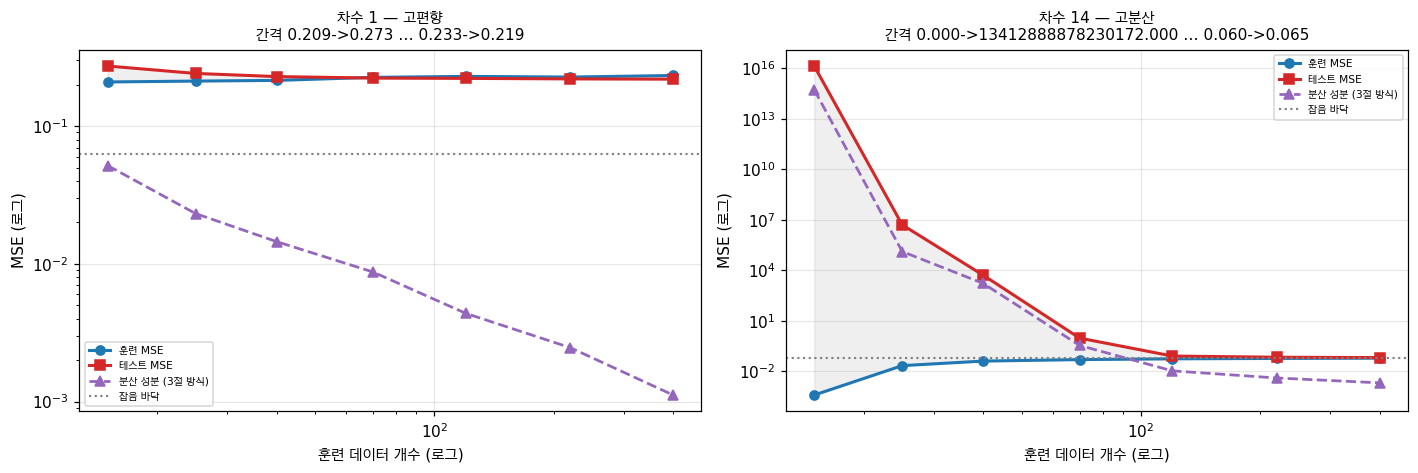

=> ⭐ **보라색 점선(분산)과 회색 띠(훈련-테스트 간격)가 같이 움직입니다.**
   학습 곡선의 '간격'이 분산을 간접적으로 재고 있다는 뜻입니다.
   그래서 진짜 함수를 몰라도 진단할 수 있는 겁니다.

   왼쪽(차수 1): 데이터를 20배 늘려도 두 선이 높은 값에서 붙어 있습니다.
   분산이 애초에 작으니 줄일 게 없고, 남은 건 편향입니다. **모델을 바꿔야 합니다.**

   오른쪽(차수 12): 간격이 계속 줄어듭니다. **데이터가 효과를 냅니다.**


In [17]:
# ✨ 추가 — 학습 곡선과 '분산 성분'이 같이 줄어드는지 겹쳐 봅니다
개수들 = [15, 25, 40, 70, 120, 220, 400]

fig, ax = plt.subplots(1, 2, figsize=(13, 4.4))
for a_, 차수, 제목 in zip(ax, [1, 14],
                          ["차수 1 — 고편향", "차수 14 — 고분산"]):
    훈련선, 테스트선, 분산선 = [], [], []
    for n in 개수들:
        t = 분해계산(차수=차수, 훈련개수=n, 반복=120)
        분산선.append(t["분산"])
        # 실제 훈련/테스트 오차도 같이 잽니다
        훈련값, 테스트값 = [], []
        for b in range(30):
            xs, ys = 데이터만들기(5000 + b, n)
            m = 다항모델(차수).fit(xs[:, None], ys)
            훈련값.append(np.mean((m.predict(xs[:, None]) - ys) ** 2))
            테스트값.append(np.mean((m.predict(x테스트[:, None]) - y테스트) ** 2))
        훈련선.append(np.mean(훈련값)); 테스트선.append(np.mean(테스트값))

    a_.plot(개수들, 훈련선, "o-", lw=2, c="tab:blue", label="훈련 MSE")
    a_.plot(개수들, 테스트선, "s-", lw=2, c="tab:red", label="테스트 MSE")
    a_.plot(개수들, 분산선, "^--", lw=1.8, c="tab:purple", label="분산 성분 (3절 방식)")
    a_.axhline(잡음표준편차**2, c="gray", ls=":", lw=1.4, label="잡음 바닥")
    a_.fill_between(개수들, 훈련선, 테스트선, alpha=0.12, color="gray")
    a_.set_xscale("log"); a_.set_yscale("log")
    a_.set_xlabel("훈련 데이터 개수 (로그)"); a_.set_ylabel("MSE (로그)")
    a_.set_title(f"{제목}\n간격 {훈련선[0]:.3f}->{테스트선[0]:.3f} … {훈련선[-1]:.3f}->{테스트선[-1]:.3f}",
                 fontsize=10)
    a_.legend(fontsize=7); a_.grid(alpha=0.3)
plt.tight_layout(); plt.show()

print("=> ⭐ **보라색 점선(분산)과 회색 띠(훈련-테스트 간격)가 같이 움직입니다.**")
print("   학습 곡선의 '간격'이 분산을 간접적으로 재고 있다는 뜻입니다.")
print("   그래서 진짜 함수를 몰라도 진단할 수 있는 겁니다.")
print("\n   왼쪽(차수 1): 데이터를 20배 늘려도 두 선이 높은 값에서 붙어 있습니다.")
print("   분산이 애초에 작으니 줄일 게 없고, 남은 건 편향입니다. **모델을 바꿔야 합니다.**")
print("\n   오른쪽(차수 12): 간격이 계속 줄어듭니다. **데이터가 효과를 냅니다.**")

---

## 🔟 🎒 Ship It — 모델 진단 프롬프트

> 📗 **원문** — 저장소의 `phases/02-ml-fundamentals/10-bias-variance/outputs/prompt-model-diagnostics.md`
> 원문은 **"측정값을 주면 진단해 주는 프롬프트"** 형태입니다.
> 우리말로 옮기고 **이 노트북의 절 번호를 붙였습니다.**
>
> 🔗 **이 절은 요약이 아니라 '진단 절차서'입니다** — 0~9절이 "편향·분산이 무엇인가"였다면,
> 여기는 **숫자를 받았을 때 순서대로 짚어 갈 목록**입니다.

### 📗 1단계 — 다음 정보를 모으세요

- [ ] **훈련 세트** 지표 (정확도, MSE, F1 등)
- [ ] **테스트/검증 세트** 지표 (같은 지표로)
- [ ] 데이터 크기 (샘플 수)
- [ ] 모델 종류와 복잡도 (예: "랜덤 포레스트 max_depth=20")

### 📗 2단계 — 진단하세요

| 진단 | 조건 | 이 노트북 |
| --- | --- | --- |
| **고편향 (과소적합)** | 훈련 오차 큼 + 테스트 오차 큼 + **간격 작음** | 1·7절 |
| **고분산 (과적합)** | 훈련 오차 작음 + 테스트 오차 큼 + **간격 큼** (상대 10~15% 초과) | 2·7절 |
| **좋은 적합** | 훈련 오차 낮음 + 테스트가 훈련에 가까움 | 7절 |
| ⚠️ **데이터 품질 문제** | 모델이 단순한데 훈련 오차가 **의심스럽게 0에 가까움** | 9단원 2절 |
| ⚠️ **잡음 바닥** | 둘 다 중간, 간격 작음, **어떤 개선도 안 먹힘** | 3·4절 |

> ⭐ **마지막 두 줄이 중요합니다.** 둘 다 "더 튜닝해도 소용없다"는 신호인데 이유가 정반대입니다.
> - **데이터 품질**: 누출을 의심하세요. 특징이 정답을 인코딩하고 있거나, 훈련·테스트에 중복 행이 있습니다
> - **잡음 바닥**: 진짜 한계에 닿은 겁니다. 3절에서 본 $\sigma^2$ 입니다

### 📗 3단계 — 학습 곡선을 해석하세요 (있다면)

| 모양 | 뜻 | 이 노트북 |
| --- | --- | --- |
| 두 곡선이 빨리 **높은 값으로 수렴**, 서로 가까움 | 데이터 추가 **소용없음.** 용량을 키우세요 | 9절 왼쪽 그림 |
| 간격 크고 데이터와 함께 **줄어드는 중** | 데이터 추가 **도움됨** | 9절 오른쪽 그림 |
| 둘 다 **낮은 값으로 수렴** | 좋은 적합 | — |
| **훈련 오차가 오르고 테스트 오차가 내려감** | ✅ **정상입니다.** 데이터가 늘어 외우기가 어려워지고, 진짜 무늬를 배우는 중 | 9절 |

### 📗 4단계 — 처방 (우선순위 순)

**고편향일 때**
1. 다항·상호작용 특징 추가
2. 더 유연한 모델 (선형 → 트리 앙상블)
3. 규제 세기 **낮추기**
4. 도메인 특화 특징 설계
5. 더 오래 학습 (수렴 전이면)

**고분산일 때**
1. **훈련 데이터 더 모으기** (가장 확실)
2. 규제 **세게** (λ↑, 드롭아웃)
3. 복잡도 줄이기 (얕은 트리, 특징 줄이기)
4. **배깅/랜덤 포레스트** (평균이 분산을 줄입니다 — 8절)
5. 특징 선택 (잡음 특징 제거)
6. 교차검증으로 안정된 추정치 얻기

**잡음 바닥일 때**
1. **더 나은 특징을 구하세요** (새 데이터 소스, 도메인 지식)
2. 기존 데이터 정제 (라벨 오류 수정, 모순 샘플 제거)
3. 현재 성능을 **한계로 받아들이기**

### 📗 출력 형식

1. **진단**: [고편향 / 고분산 / 좋은 적합 / 데이터 문제 / 잡음 바닥]
2. **근거**: 그 판단을 뒷받침하는 **구체적 숫자**
3. **근본 원인**: 이 모델과 데이터에서 왜 이런 일이 생기나
4. **처방 (순위순)**: 효과 큰 것부터
5. **하지 말 것**: 이 진단에서 흔히 하는 잘못된 대응

---

### ⚠️ 📗 원문이 명시한 '하지 말 것'

| 하지 말 것 | 왜 |
| --- | --- |
| **고편향에 "데이터를 더 모으세요"**를 첫 처방으로 | 3절에서 봤듯 **편향²은 데이터로 안 줄어듭니다** |
| **고분산에 더 복잡한 모델** 권하기 | 4절의 U자에서 **더 오른쪽으로 가는 겁니다.** 나빠집니다 |
| 훈련·테스트가 **둘 다 큰데 과적합**이라 진단 | 그건 **과소적합**입니다. 간격을 보세요 |
| 훈련 정확도가 100% 근처인데 **누출을 의심하지 않기** | 9단원 2절에서 봤듯 누출은 **경고 없이** 일어납니다 |

---

## 1️⃣1️⃣ 📝 자가 점검 퀴즈

> 📗 **원문** — 저장소의 `phases/02-ml-fundamentals/10-bias-variance/quiz.json`
> 우리말로 옮기고, 각 문항이 이 노트북 **몇 절**에 있는지 표시했습니다.
>
> 💡 클론한 저장소가 있으면 Claude Code에서 `/check-understanding 2` 로도 풀 수 있습니다.

**먼저 답을 정한 뒤에** 아래 코드 셀을 실행해 정답을 확인하세요.

### 사전 점검 — 배우기 전에 알았어야 하는 것

**1. 분명히 휘어 있는(2차) 관계에 선형 모델을 맞췄습니다. 어느 오차 성분이 지배할까요?**

1. 편향: 모델이 너무 뻣뻣해서 진짜 비선형 무늬를 못 잡는다
2. 분산: 훈련 데이터에 따라 모델이 너무 많이 변한다
3. 줄일 수 없는 잡음: 데이터가 너무 지저분하다
4. 없음: 모델이 완벽히 맞아야 한다

**2. 오차 분해의 세 항 중, 어떤 모델로도 줄일 수 없는 것은?**

1. 셋 다 0으로 줄일 수 있다
2. 분산
3. 줄일 수 없는 잡음 ($\sigma^2$)
4. 편향의 제곱

### 사후 점검 — 이 단원을 배운 뒤에 알아야 하는 것

**3. L2 규제를 넣으면 편향이 늘고 분산이 줍니다. 그게 왜 유용한가요?**

1. 분산 감소가 편향 증가를 능가해서 전체 오차가 내려갈 수 있다
2. 모델 학습이 빨라진다
3. L2 규제가 줄일 수 없는 잡음을 없앤다
4. 훈련 정확도와 테스트 정확도를 항상 둘 다 올려 준다

**4. 모델의 훈련 오차가 2%, 테스트 오차가 25%입니다. 가장 가능성 높은 진단은?**

1. 줄일 수 없는 잡음이 크다: 데이터가 너무 지저분하다
2. 고편향 (과소적합): 모델이 너무 단순하다
3. 고분산 (과적합): 훈련 데이터를 외워서 일반화에 실패했다
4. 모델이 완벽하게 보정되어 있다

**5. 같은 모델 구조를 서로 다른 무작위 훈련 부분집합 50개로 학습시켰더니 예측이 제각각입니다. 무엇을 뜻하나요?**

1. 줄일 수 없는 잡음이 크다: 목표 변수가 무작위다
2. 고편향: 모델이 진짜 무늬를 일관되게 놓친다
3. 학습률이 너무 높다
4. 고분산: 어떤 훈련 데이터를 보느냐에 모델이 민감하다

In [18]:
# 📝 정답과 해설 (+ 이 노트북 어디서 다뤘는지)
퀴즈 = [
    ("1. 휜 관계에 선형 모델 -> 어느 성분?", 1,
     "선형 모델은 데이터를 얼마나 많이 줘도 2차 곡선을 잡을 수 없습니다. 모델 가정이 틀려서 "
     "생기는 이 체계적 오차가 편향입니다. 과소적합이죠.",
     "0절 (차수 1의 진단) · 1절 (모델 60개를 평균해도 진실과 벌어짐)"),
    ("2. 어떤 모델로도 못 줄이는 항", 3,
     "줄일 수 없는 잡음은 데이터 자체의 무작위성(측정 오차, 빠진 변수)에서 옵니다. "
     "어떤 모델도 잡음을 예측할 수 없습니다. 기대 오차 = 편향² + 분산 + 줄일 수 없는 잡음.",
     "3절 (σ=0으로 바꿔 이 항이 0이 되는 걸 확인) · 4절 (회색 점선이 바닥)"),
    ("3. L2 규제가 유용한 이유", 1,
     "규제는 편향을 조금 늘리는 대가로 분산을 더 많이 줄입니다. 모델이 과적합 중이면(고분산) "
     "이 맞바꿈으로 편향이 올라가도 전체 오차가 내려갑니다.",
     "5절 — 차수 15 고정하고 λ를 돌려서 편향²↑ 분산↓ 전체↓ 를 직접 측정했습니다"),
    ("4. 훈련 2% / 테스트 25% 진단", 3,
     "낮은 훈련 오차 + 높은 테스트 오차 + 큰 간격 = 고분산(과적합). 모델이 훈련 데이터 "
     "특유의 잡음을 맞추고 있습니다. 처방: 규제, 복잡도 줄이기, 데이터 추가.",
     "7절 — 진단기를 코드로 만들어 모델 5개를 진단했습니다"),
    ("5. 훈련 부분집합마다 예측이 제각각", 4,
     "분산은 서로 다른 데이터 부분집합으로 학습했을 때 예측이 얼마나 변하는지를 재는 값입니다. "
     "부분집합마다 예측이 제각각인 것이 고분산의 정의 그대로입니다.",
     "2절 — 훈련 세트 60개로 학습한 모델들의 ±1 표준편차 띠를 그렸습니다"),
]

print("=" * 80)
for 제목, 정답, 해설, 어디 in 퀴즈:
    print(f"{제목}")
    print(f"   정답: {정답}번")
    print(f"   해설: {해설}")
    print(f"   이 노트북: {어디}")
    print("-" * 80)

print("\n💡 채점 기준")
print("   5개 다 맞음 -> 11단원(앙상블 방법)으로 넘어가세요")
print("   3~4개 맞음  -> 틀린 문항의 '이 노트북' 절만 다시 읽으세요")
print("   2개 이하    -> 3절(분해 계산)을 먼저 다시 보세요. 나머지 절이 다 거기서 나옵니다")

1. 휜 관계에 선형 모델 -> 어느 성분?
   정답: 1번
   해설: 선형 모델은 데이터를 얼마나 많이 줘도 2차 곡선을 잡을 수 없습니다. 모델 가정이 틀려서 생기는 이 체계적 오차가 편향입니다. 과소적합이죠.
   이 노트북: 0절 (차수 1의 진단) · 1절 (모델 60개를 평균해도 진실과 벌어짐)
--------------------------------------------------------------------------------
2. 어떤 모델로도 못 줄이는 항
   정답: 3번
   해설: 줄일 수 없는 잡음은 데이터 자체의 무작위성(측정 오차, 빠진 변수)에서 옵니다. 어떤 모델도 잡음을 예측할 수 없습니다. 기대 오차 = 편향² + 분산 + 줄일 수 없는 잡음.
   이 노트북: 3절 (σ=0으로 바꿔 이 항이 0이 되는 걸 확인) · 4절 (회색 점선이 바닥)
--------------------------------------------------------------------------------
3. L2 규제가 유용한 이유
   정답: 1번
   해설: 규제는 편향을 조금 늘리는 대가로 분산을 더 많이 줄입니다. 모델이 과적합 중이면(고분산) 이 맞바꿈으로 편향이 올라가도 전체 오차가 내려갑니다.
   이 노트북: 5절 — 차수 15 고정하고 λ를 돌려서 편향²↑ 분산↓ 전체↓ 를 직접 측정했습니다
--------------------------------------------------------------------------------
4. 훈련 2% / 테스트 25% 진단
   정답: 3번
   해설: 낮은 훈련 오차 + 높은 테스트 오차 + 큰 간격 = 고분산(과적합). 모델이 훈련 데이터 특유의 잡음을 맞추고 있습니다. 처방: 규제, 복잡도 줄이기, 데이터 추가.
   이 노트북: 7절 — 진단기를 코드로 만들어 모델 5개를 진단했습니다
-----------------------------------------

---

## 1️⃣2️⃣ 용어 사전

> 📗 **원문** — "Key Terms" (설명은 쉬운 말로 다시 썼습니다)

| 용어 | 흔히 하는 말 | 진짜 무슨 뜻인가 |
| --- | --- | --- |
| **편향 (bias)** | "모델이 너무 단순해" | 잘못된 가정에서 오는 **체계적** 오차. 모델 평균 예측과 진실의 차이. **평균을 내도 안 사라집니다** |
| **분산 (variance)** | "모델이 과적합해" | 훈련 데이터에 민감해서 생기는 오차. 데이터를 바꿀 때 예측이 얼마나 달라지나 |
| **줄일 수 없는 오차** | "데이터에 잡음이 있어" | 데이터 생성 과정 자체의 무작위성. **어떤 모델도 없앨 수 없습니다** |
| **과소적합** | "학습이 덜 됐어" | 편향이 큰 상태. 훈련 데이터에서조차 무늬를 놓칩니다 |
| **과적합** | "데이터를 외웠어" | 분산이 큰 상태. 일반화되지 않는 훈련 데이터 잡음을 맞춥니다 |
| **규제** | "모델을 묶어 두기" | 벌점을 더해 복잡도를 줄이는 것. **편향을 주고 분산을 사 오는 거래** |
| **이중 하강** | "파라미터가 많으면 더 좋아" | 용량이 보간 임곗값을 **훨씬** 넘어가면 테스트 오차가 다시 내려가는 현상 |
| **보간 임곗값** | "딱 맞출 수 있는 지점" | 파라미터 수 ≈ 샘플 수. **가장 나쁜 자리입니다** |
| **암묵적 규제** | "알아서 단순해져" | 해가 여러 개일 때 학습 알고리즘이 가장 단순한 걸 고르는 성향 (예: 최소 노름 해) |
| **모델 복잡도** | "모델이 얼마나 유연한가" | 임의의 무늬를 맞출 수 있는 용량. 구조·특징·규제로 조절합니다 |

---

## ✅ 이 단원 요약 (7줄)

1. **오차 = 편향² + 분산 + 줄일 수 없는 잡음.** 3절에서 등식이 맞는 걸 직접 계산했습니다.
2. **편향은 평균을 내도 안 사라집니다.** 그래서 '체계적'이고, **데이터로는 안 고쳐집니다.**
3. **분산은 데이터를 늘리면 줄어듭니다.** 3절에서 15개→300개로 분산만 줄어드는 걸 확인했습니다.
4. 복잡도를 올리면 편향²↓ 분산↑. 합이 **U자**가 되고 바닥이 최적입니다.
5. **규제는 일부러 편향을 늘려 분산을 사 오는 거래**입니다. 이득이 크면 전체가 줄어듭니다.
6. 🔑 **고전 U자는 불완전합니다.** 보간 임곗값(p≈n)을 한참 지나면 오차가 **다시 내려갑니다.**
   6절에서 p=40에서 테스트 MSE가 폭발하고 p=80에서 회복되는 걸 재현했습니다.
7. 실무에서는 **훈련/테스트 간격**으로 간접 진단합니다. 간격이 분산을 재고 있기 때문입니다(9절).

> ⚠️ **가장 중요한 실무 교훈**: 편향과 분산의 처방은 **정반대**입니다.
> 진단을 틀리면 노력이 전부 헛수고가 됩니다.

---

## 📝 연습문제

> 📗 **원문** — "Exercises" (대부분 본문에서 풀었습니다)

1. `noise_std=0` 으로 분해를 돌려 보세요. 줄일 수 없는 오차 항은 어떻게 되나요? 최적 복잡도가 바뀌나요? → *3절에서 함*
2. 훈련 데이터를 30개에서 300개로 늘려 보세요. 분산 성분은 어떻게 되나요? → *3절에서 함*
3. 차수 15를 고정하고 L2 규제 λ를 0~100으로 훑어 편향²과 분산을 그려 보세요. → *5절에서 함*
4. 진짜 함수를 다항식에서 `sin(x)` 로 바꿔 보세요. 분해가 어떻게 달라지나요? 명확한 최적 차수가 여전히 있나요?
5. 배깅 래퍼를 만들어 부트스트랩 표본 10개로 학습한 모델을 평균하세요. 편향을 크게 늘리지 않고 분산이 줄어드는지 보이세요. → *8절에서 함*

### ✨ 추가 도전 과제

6. 6절의 이중 하강에서 **잡음을 0으로** 만들어 보세요. 봉우리가 사라지나요? (힌트: 원문은 "규제가 봉우리를 완만하게 만들지만 없애지 못한다"고 합니다)
7. 6절에 **릿지 규제를 추가**해 보세요 (`pinv` 대신 `Ridge(alpha=...)`). λ가 커질수록 봉우리가 어떻게 변하나요?
8. 8절 배깅 실험에서 **모델을 더 독립적으로** 만들어 보세요 (각 모델에 특징을 무작위로 뽑아 주기). 분산 감소가 $1/N$ 에 더 가까워지나요?
9. 4단원 7절 랜덤 포레스트에 **나무 수를 바꿔 가며** 3절 방식으로 편향²과 분산을 분해해 보세요. 원문 표의 "배깅: 편향 변화 없음"이 트리에서도 맞나요?
10. 9단원 8절의 검증 곡선을 **편향²·분산 분해와 겹쳐** 그려 보세요. 검증 점수 최고점이 U자 바닥과 일치하나요?

---

## 📚 더 읽을거리

> 📗 **원문** — "Further Reading"

- [Hastie, Tibshirani, Friedman: Elements of Statistical Learning 7장](https://hastie.su.domains/ElemStatLearn/) — 편향-분산 분해의 결정판
- [Belkin et al., Reconciling modern ML practice and the bias-variance trade-off (2019)](https://arxiv.org/abs/1812.11118) — **이중 하강 원 논문**
- [Nakkiran et al., Deep Double Descent (2019)](https://arxiv.org/abs/1912.02292) — 에폭·샘플 이중 하강
- [Scott Fortmann-Roe: Understanding the Bias-Variance Tradeoff](http://scott.fortmann-roe.com/docs/BiasVariance.html) — 그림으로 보는 설명